# Customer Segmentation: Baseline, Clustering and Evaluation

**Module:** IT3091 – Machine Learning  
**Group:** 2026-DS-10  
**Responsible member:** Palliyaguruge C.T. (IT24103655)  
**Input prepared by:** Nirmani K.H.D.T. (IT24103380)  
**Random seed:** 42  

## Objectives

1. Develop an interpretable RFM segmentation baseline.
2. Compare multiple clustering algorithms.
3. Compare core RFM and enhanced behavioural feature sets.
4. Evaluate raw and log-transformed representations.
5. Compare StandardScaler and RobustScaler.
6. Select the final model using internal metrics, cluster balance, stability and business interpretability.
7. Profile the final customer segments for downstream association mining.

## Candidate Methods

- RFM quantile scoring baseline
- K-Means clustering
- Agglomerative clustering
- Gaussian Mixture Model
- DBSCAN density-based clustering

No customer records will be automatically deleted as statistical outliers.

In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

print("Libraries imported successfully.")
print("Random seed:", RANDOM_STATE)

Libraries imported successfully.
Random seed: 42


In [2]:
current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DOCUMENTATION_DIR = PROJECT_ROOT / "documentation"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

feature_paths = {
    "core_raw": PROCESSED_DIR / "core_rfm_raw.csv",
    "core_log": PROCESSED_DIR / "core_rfm_log.csv",
    "enhanced_raw": PROCESSED_DIR / "enhanced_features_raw.csv",
    "enhanced_log": PROCESSED_DIR / "enhanced_features_log.csv",
    "full_features": PROCESSED_DIR / "full_customer_features.csv",
}

print("Project root:", PROJECT_ROOT)

for dataset_name, dataset_path in feature_paths.items():
    print(f"{dataset_name:15s}: {dataset_path.exists()} | {dataset_path.name}")

Project root: /Users/lakshithadilshan/Documents/online-retail-customer-analytics
core_raw       : True | core_rfm_raw.csv
core_log       : True | core_rfm_log.csv
enhanced_raw   : True | enhanced_features_raw.csv
enhanced_log   : True | enhanced_features_log.csv
full_features  : True | full_customer_features.csv


In [3]:
datasets = {
    name: pd.read_csv(path)
    for name, path in feature_paths.items()
}

core_raw = datasets["core_raw"]
core_log = datasets["core_log"]
enhanced_raw = datasets["enhanced_raw"]
enhanced_log = datasets["enhanced_log"]
full_features = datasets["full_features"]

validation_rows = []

for name, dataframe in datasets.items():
    numeric_values = dataframe.select_dtypes(include="number").to_numpy()

    validation_rows.append({
        "Dataset": name,
        "Rows": len(dataframe),
        "Columns": dataframe.shape[1],
        "Unique_Customers": dataframe["CustomerID"].nunique(),
        "Duplicate_Customers": dataframe["CustomerID"].duplicated().sum(),
        "Missing_Values": dataframe.isna().sum().sum(),
        "Infinite_Values": (
            np.isinf(numeric_values).sum()
            if numeric_values.size > 0
            else 0
        )
    })

validation_summary = pd.DataFrame(validation_rows)

assert len(core_raw) == 4334
assert len(core_log) == 4334
assert len(enhanced_raw) == 4334
assert len(enhanced_log) == 4334

for name in ["core_raw", "core_log", "enhanced_raw", "enhanced_log"]:
    dataframe = datasets[name]

    assert dataframe["CustomerID"].is_unique
    assert dataframe.isna().sum().sum() == 0
    assert np.isfinite(
        dataframe.select_dtypes(include="number").to_numpy()
    ).all()

print("Clustering-input quality checks passed.")

display(validation_summary)
display(core_raw.head())
display(enhanced_raw.head())

Clustering-input quality checks passed.


,Dataset,Rows,Columns,Unique_Customers,Duplicate_Customers,Missing_Values,Infinite_Values
0,core_raw,4334,4,4334,0,0,0
1,core_log,4334,4,4334,0,0,0
2,enhanced_raw,4334,6,4334,0,0,0
3,enhanced_log,4334,6,4334,0,0,0
4,full_features,4334,14,4334,0,1505,0


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,3,7,"4,310.00"
2,12348,76,4,"1,437.24"
3,12349,19,1,"1,457.55"
4,12350,311,1,294.40


,CustomerID,Recency,Frequency,Monetary,ProductDiversity,AverageBasketSize
0,12346,326,1,"77,183.60",1,1.00
1,12347,3,7,"4,310.00",103,26.00
2,12348,76,4,"1,437.24",21,5.75
3,12349,19,1,"1,457.55",72,72.00
4,12350,311,1,294.40,16,16.00


## 1. Interpretable RFM Baseline

Before applying unsupervised clustering algorithms, customers are assigned quartile-based RFM scores.

- Lower Recency indicates a more recent and therefore stronger customer.
- Higher Frequency indicates more purchasing occasions.
- Higher Monetary indicates greater customer value.
- Each variable receives a score from 1 to 4.
- The combined RFM score provides a transparent rule-based baseline.

Percentile ranks are used instead of direct `qcut` boundaries because Frequency contains many tied values. This preserves equal scores for customers with equal observed values.

In [4]:
rfm_baseline = core_raw.copy()

quantile_groups = 4

recency_percentile = rfm_baseline["Recency"].rank(
    method="average",
    pct=True
)

frequency_percentile = rfm_baseline["Frequency"].rank(
    method="average",
    pct=True
)

monetary_percentile = rfm_baseline["Monetary"].rank(
    method="average",
    pct=True
)

rfm_baseline["R_Score"] = (
    5 - np.ceil(recency_percentile * quantile_groups)
).clip(1, 4).astype(int)

rfm_baseline["F_Score"] = (
    np.ceil(frequency_percentile * quantile_groups)
).clip(1, 4).astype(int)

rfm_baseline["M_Score"] = (
    np.ceil(monetary_percentile * quantile_groups)
).clip(1, 4).astype(int)

rfm_baseline["RFM_Total"] = (
    rfm_baseline["R_Score"]
    + rfm_baseline["F_Score"]
    + rfm_baseline["M_Score"]
)

rfm_baseline["RFM_Code"] = (
    rfm_baseline["R_Score"].astype(str)
    + rfm_baseline["F_Score"].astype(str)
    + rfm_baseline["M_Score"].astype(str)
)

assert rfm_baseline[["R_Score", "F_Score", "M_Score"]].isin(
    [1, 2, 3, 4]
).all().all()

assert rfm_baseline["RFM_Total"].between(3, 12).all()
assert rfm_baseline["CustomerID"].is_unique

print("RFM baseline scoring completed.")
display(rfm_baseline.head())

RFM baseline scoring completed.


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,RFM_Code
0,12346,326,1,"77,183.60",1,1,4,6,114
1,12347,3,7,"4,310.00",4,4,4,12,444
2,12348,76,4,"1,437.24",2,3,3,8,233
3,12349,19,1,"1,457.55",3,1,3,7,313
4,12350,311,1,294.40,1,1,1,3,111


In [5]:
def assign_rfm_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r == 4 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r == 4 and f <= 2:
        return "Recent Customers"
    elif r >= 3 and f <= 2 and m >= 3:
        return "Promising High Value"
    elif r == 2 and f >= 3:
        return "Needs Attention"
    elif r == 1 and f >= 3 and m >= 3:
        return "At Risk High Value"
    elif r == 1 and f <= 2:
        return "Hibernating"
    else:
        return "Developing Customers"


rfm_baseline["BaselineSegment"] = rfm_baseline.apply(
    assign_rfm_segment,
    axis=1
)

baseline_segment_summary = (
    rfm_baseline
    .groupby("BaselineSegment", as_index=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        Mean_Recency=("Recency", "mean"),
        Mean_Frequency=("Frequency", "mean"),
        Mean_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
)

baseline_segment_summary["Customer_Percentage"] = (
    baseline_segment_summary["Customers"]
    / rfm_baseline["CustomerID"].nunique()
    * 100
)

baseline_segment_summary["Revenue_Percentage"] = (
    baseline_segment_summary["Total_Revenue"]
    / rfm_baseline["Monetary"].sum()
    * 100
)

baseline_segment_summary = baseline_segment_summary.sort_values(
    "Customers",
    ascending=False
).reset_index(drop=True)

assert baseline_segment_summary["Customers"].sum() == 4334
assert np.isclose(
    baseline_segment_summary["Customer_Percentage"].sum(),
    100
)
assert np.isclose(
    baseline_segment_summary["Revenue_Percentage"].sum(),
    100
)

display(baseline_segment_summary)

,BaselineSegment,Customers,Mean_Recency,Mean_Frequency,Mean_Monetary,Total_Revenue,Customer_Percentage,Revenue_Percentage
0,Developing Customers,1090,72.70,1.46,463.01,"504,682.03",25.15,5.78
1,Hibernating,950,253.95,1.25,480.76,"456,726.07",21.92,5.23
2,Champions,779,8.33,11.41,"6,168.97","4,805,628.90",17.97,55.00
3,Loyal Customers,660,29.31,5.81,"2,449.08","1,616,391.07",15.23,18.50
4,Needs Attention,427,83.85,4.55,"1,702.67","727,040.46",9.85,8.32
5,Recent Customers,259,10.05,1.61,"1,148.93","297,571.94",5.98,3.41
6,Promising High Value,90,34.22,1.80,"1,218.48","109,663.51",2.08,1.26
7,At Risk High Value,79,205.48,4.90,"2,778.78","219,523.66",1.82,2.51


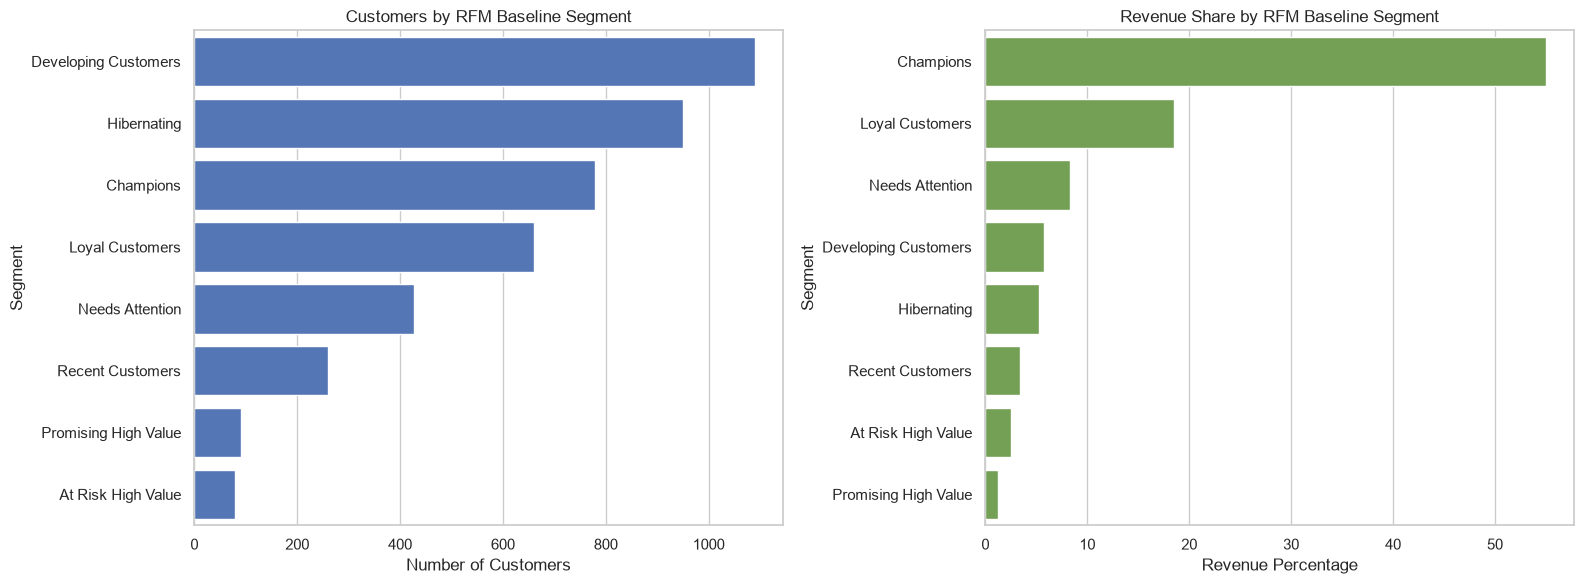

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/rfm_baseline_segment_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=baseline_segment_summary,
    y="BaselineSegment",
    x="Customers",
    color="#4472C4",
    ax=axes[0]
)

axes[0].set_title("Customers by RFM Baseline Segment")
axes[0].set_xlabel("Number of Customers")
axes[0].set_ylabel("Segment")

sns.barplot(
    data=baseline_segment_summary.sort_values(
        "Revenue_Percentage",
        ascending=False
    ),
    y="BaselineSegment",
    x="Revenue_Percentage",
    color="#70AD47",
    ax=axes[1]
)

axes[1].set_title("Revenue Share by RFM Baseline Segment")
axes[1].set_xlabel("Revenue Percentage")
axes[1].set_ylabel("Segment")

plt.tight_layout()

baseline_figure_path = (
    FIGURES_DIR / "rfm_baseline_segment_distribution.png"
)

plt.savefig(
    baseline_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", baseline_figure_path)

## 2. Feature Representation and Scaling

Eight preprocessing configurations are evaluated:

- Core RFM: raw and log1p-transformed
- Enhanced behavioural features: raw and log1p-transformed
- StandardScaler and RobustScaler for every representation

Scaling is fitted separately within each configuration. CustomerID is retained only as an identifier and is never used as a clustering feature.

In [7]:
source_datasets = {
    "Core_Raw": core_raw,
    "Core_Log": core_log,
    "Enhanced_Raw": enhanced_raw,
    "Enhanced_Log": enhanced_log,
}

scaler_options = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
}

scaled_configurations = {}
configuration_rows = []

for dataset_name, dataframe in source_datasets.items():
    feature_columns = [
        column
        for column in dataframe.columns
        if column != "CustomerID"
    ]

    X = dataframe[feature_columns].copy()

    for scaler_name, scaler in scaler_options.items():
        configuration_name = f"{dataset_name}_{scaler_name}"

        X_scaled = scaler.fit_transform(X)

        assert X_scaled.shape[0] == 4334
        assert X_scaled.shape[1] == len(feature_columns)
        assert np.isfinite(X_scaled).all()

        scaled_configurations[configuration_name] = {
            "X": X_scaled,
            "CustomerID": dataframe["CustomerID"].to_numpy(),
            "Features": feature_columns,
            "Scaler": scaler,
            "Source_Data": dataframe.copy(),
        }

        configuration_rows.append({
            "Configuration": configuration_name,
            "Feature_Set": dataset_name,
            "Scaler": scaler_name,
            "Customers": X_scaled.shape[0],
            "Feature_Count": X_scaled.shape[1],
            "Features": ", ".join(feature_columns),
        })

configuration_summary = pd.DataFrame(configuration_rows)

print("Scaled configurations created:", len(scaled_configurations))
display(configuration_summary)

Scaled configurations created: 8


,Configuration,Feature_Set,Scaler,Customers,Feature_Count,Features
0,Core_Raw_StandardScaler,Core_Raw,StandardScaler,4334,3,"Recency, Frequency, Monetary"
1,Core_Raw_RobustScaler,Core_Raw,RobustScaler,4334,3,"Recency, Frequency, Monetary"
2,Core_Log_StandardScaler,Core_Log,StandardScaler,4334,3,"Log_Recency, Log_Frequency, Log_Monetary"
3,Core_Log_RobustScaler,Core_Log,RobustScaler,4334,3,"Log_Recency, Log_Frequency, Log_Monetary"
4,Enhanced_Raw_StandardScaler,Enhanced_Raw,StandardScaler,4334,5,"Recency, Frequency, Monetary, ProductDiversity..."
5,Enhanced_Raw_RobustScaler,Enhanced_Raw,RobustScaler,4334,5,"Recency, Frequency, Monetary, ProductDiversity..."
6,Enhanced_Log_StandardScaler,Enhanced_Log,StandardScaler,4334,5,"Log_Recency, Log_Frequency, Log_Monetary, Log_..."
7,Enhanced_Log_RobustScaler,Enhanced_Log,RobustScaler,4334,5,"Log_Recency, Log_Frequency, Log_Monetary, Log_..."


In [8]:
def evaluate_partition(X, labels, silhouette_sample_size=2000):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    non_noise_mask = labels != -1
    evaluated_labels = labels[non_noise_mask]
    evaluated_X = X[non_noise_mask]

    unique_non_noise = np.unique(evaluated_labels)

    if len(unique_non_noise) < 2:
        return {
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan,
            "Smallest_Cluster_Percentage": np.nan,
            "Largest_Cluster_Percentage": np.nan,
            "Noise_Percentage": (labels == -1).mean() * 100,
        }

    sample_size = min(
        silhouette_sample_size,
        len(evaluated_X)
    )

    silhouette = silhouette_score(
        evaluated_X,
        evaluated_labels,
        sample_size=sample_size,
        random_state=RANDOM_STATE
    )

    cluster_counts = pd.Series(
        evaluated_labels
    ).value_counts(normalize=True) * 100

    return {
        "Silhouette": silhouette,
        "Davies_Bouldin": davies_bouldin_score(
            evaluated_X,
            evaluated_labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            evaluated_X,
            evaluated_labels
        ),
        "Smallest_Cluster_Percentage": cluster_counts.min(),
        "Largest_Cluster_Percentage": cluster_counts.max(),
        "Noise_Percentage": (labels == -1).mean() * 100,
    }

In [10]:
def evaluate_partition(X, labels, silhouette_sample_size=2000):
    labels = np.asarray(labels)

    non_noise_mask = labels != -1
    evaluated_X = X[non_noise_mask]
    evaluated_labels = labels[non_noise_mask]

    unique_non_noise = np.unique(evaluated_labels)

    if (
        len(unique_non_noise) < 2
        or len(unique_non_noise) >= len(evaluated_labels)
    ):
        return {
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan,
            "Smallest_Cluster_Percentage": np.nan,
            "Largest_Cluster_Percentage": np.nan,
            "Noise_Percentage": (labels == -1).mean() * 100,
        }

    rng = np.random.default_rng(RANDOM_STATE)

    # Ensure that every cluster is represented in the silhouette sample.
    mandatory_indices = []

    for cluster_label in unique_non_noise:
        cluster_indices = np.flatnonzero(
            evaluated_labels == cluster_label
        )

        mandatory_indices.append(
            rng.choice(cluster_indices)
        )

    mandatory_indices = np.asarray(
        mandatory_indices,
        dtype=int
    )

    target_sample_size = min(
        silhouette_sample_size,
        len(evaluated_X)
    )

    remaining_sample_size = (
        target_sample_size - len(mandatory_indices)
    )

    all_indices = np.arange(len(evaluated_X))

    available_indices = np.setdiff1d(
        all_indices,
        mandatory_indices,
        assume_unique=False
    )

    if remaining_sample_size > 0:
        additional_indices = rng.choice(
            available_indices,
            size=min(
                remaining_sample_size,
                len(available_indices)
            ),
            replace=False
        )

        sample_indices = np.concatenate(
            [mandatory_indices, additional_indices]
        )
    else:
        sample_indices = mandatory_indices

    sampled_X = evaluated_X[sample_indices]
    sampled_labels = evaluated_labels[sample_indices]

    silhouette = silhouette_score(
        sampled_X,
        sampled_labels
    )

    cluster_counts = (
        pd.Series(evaluated_labels)
        .value_counts(normalize=True)
        * 100
    )

    return {
        "Silhouette": silhouette,
        "Davies_Bouldin": davies_bouldin_score(
            evaluated_X,
            evaluated_labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            evaluated_X,
            evaluated_labels
        ),
        "Smallest_Cluster_Percentage": cluster_counts.min(),
        "Largest_Cluster_Percentage": cluster_counts.max(),
        "Noise_Percentage": (labels == -1).mean() * 100,
    }

print("Revised partition-evaluation function loaded.")

Revised partition-evaluation function loaded.


In [11]:
kmeans_results = []
kmeans_label_store = {}

for configuration_name, configuration in scaled_configurations.items():
    X = configuration["X"]

    for k in range(2, 11):
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=20
        )

        labels = model.fit_predict(X)
        metrics = evaluate_partition(X, labels)

        experiment_id = f"KMeans_{configuration_name}_k{k}"

        kmeans_label_store[experiment_id] = labels

        kmeans_results.append({
            "Experiment_ID": experiment_id,
            "Algorithm": "KMeans",
            "Configuration": configuration_name,
            "Feature_Set": configuration_name.rsplit("_", 1)[0],
            "Scaler": configuration_name.rsplit("_", 1)[1],
            "K": k,
            "Inertia": model.inertia_,
            **metrics,
        })

kmeans_results_df = pd.DataFrame(kmeans_results)

assert len(kmeans_results_df) == 72
assert kmeans_results_df["Experiment_ID"].is_unique

print("K-Means experiments completed:", len(kmeans_results_df))

display(
    kmeans_results_df
    .sort_values(
        ["Silhouette", "Davies_Bouldin"],
        ascending=[False, True]
    )
    .head(15)
)

K-Means experiments completed: 72


,Experiment_ID,Algorithm,Configuration,Feature_Set,Scaler,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Noise_Percentage
9,KMeans_Core_Raw_RobustScaler_k2,KMeans,Core_Raw_RobustScaler,Core_Raw,RobustScaler,2,"81,661.84",0.98,0.37,"6,995.06",0.18,99.82,0.00
45,KMeans_Enhanced_Raw_RobustScaler_k2,KMeans,Enhanced_Raw_RobustScaler,Enhanced_Raw,RobustScaler,2,"94,474.66",0.97,0.38,"6,069.59",0.18,99.82,0.00
10,KMeans_Core_Raw_RobustScaler_k3,KMeans,Core_Raw_RobustScaler,Core_Raw,RobustScaler,3,"44,736.08",0.95,0.48,"8,170.40",0.12,99.22,0.00
46,KMeans_Enhanced_Raw_RobustScaler_k3,KMeans,Enhanced_Raw_RobustScaler,Enhanced_Raw,RobustScaler,3,"57,323.64",0.92,0.54,"6,403.92",0.14,99.12,0.00
0,KMeans_Core_Raw_StandardScaler_k2,KMeans,Core_Raw_StandardScaler,Core_Raw,StandardScaler,2,"9,008.00",0.91,0.74,"1,920.74",0.58,99.42,0.00
36,KMeans_Enhanced_Raw_StandardScaler_k2,KMeans,Enhanced_Raw_StandardScaler,Enhanced_Raw,StandardScaler,2,"16,883.88",0.89,0.80,"1,228.01",0.39,99.61,0.00
11,KMeans_Core_Raw_RobustScaler_k4,KMeans,Core_Raw_RobustScaler,Core_Raw,RobustScaler,4,"32,866.78",0.75,0.60,"7,933.53",0.09,93.24,0.00
12,KMeans_Core_Raw_RobustScaler_k5,KMeans,Core_Raw_RobustScaler,Core_Raw,RobustScaler,5,"22,557.88",0.74,0.58,"9,161.93",0.05,92.59,0.00
47,KMeans_Enhanced_Raw_RobustScaler_k4,KMeans,Enhanced_Raw_RobustScaler,Enhanced_Raw,RobustScaler,4,"43,864.66",0.65,0.72,"6,020.81",0.09,91.12,0.00
13,KMeans_Core_Raw_RobustScaler_k6,KMeans,Core_Raw_RobustScaler,Core_Raw,RobustScaler,6,"18,596.30",0.65,0.63,"9,073.31",0.05,88.44,0.00


In [12]:
best_kmeans_by_configuration = (
    kmeans_results_df
    .sort_values(
        [
            "Configuration",
            "Silhouette",
            "Davies_Bouldin",
            "Smallest_Cluster_Percentage"
        ],
        ascending=[True, False, True, False]
    )
    .groupby("Configuration", as_index=False)
    .first()
    .sort_values(
        "Silhouette",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    best_kmeans_by_configuration[
        [
            "Configuration",
            "K",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
            "Smallest_Cluster_Percentage",
            "Largest_Cluster_Percentage",
            "Inertia"
        ]
    ]
)

,Configuration,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Inertia
0,Core_Raw_RobustScaler,2,0.98,0.37,"6,995.06",0.18,99.82,"81,661.84"
1,Enhanced_Raw_RobustScaler,2,0.97,0.38,"6,069.59",0.18,99.82,"94,474.66"
2,Core_Raw_StandardScaler,2,0.91,0.74,"1,920.74",0.58,99.42,"9,008.00"
3,Enhanced_Raw_StandardScaler,2,0.89,0.80,"1,228.01",0.39,99.61,"16,883.88"
4,Core_Log_StandardScaler,2,0.43,0.89,"4,373.79",38.35,61.65,"6,469.81"
5,Core_Log_RobustScaler,2,0.43,0.89,"4,388.74",39.34,60.66,"2,931.74"
6,Enhanced_Log_StandardScaler,2,0.34,1.11,"2,878.46",43.86,56.14,"13,019.21"
7,Enhanced_Log_RobustScaler,2,0.33,1.12,"2,824.50",48.96,51.04,"6,669.25"


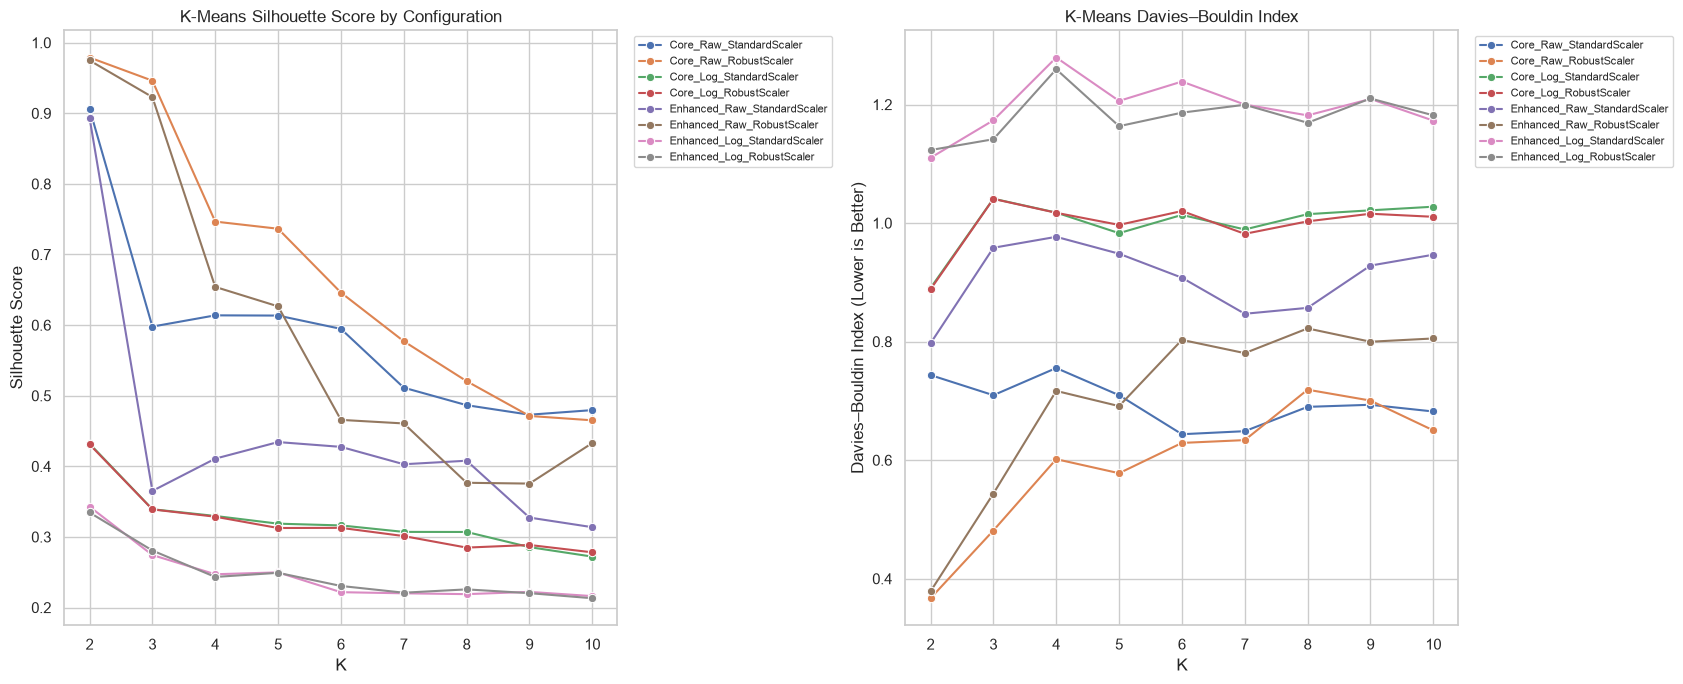

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/kmeans_configuration_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.lineplot(
    data=kmeans_results_df,
    x="K",
    y="Silhouette",
    hue="Configuration",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("K-Means Silhouette Score by Configuration")
axes[0].set_ylabel("Silhouette Score")
axes[0].legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

sns.lineplot(
    data=kmeans_results_df,
    x="K",
    y="Davies_Bouldin",
    hue="Configuration",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("K-Means Davies–Bouldin Index")
axes[1].set_ylabel("Davies–Bouldin Index (Lower is Better)")
axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

kmeans_figure_path = (
    FIGURES_DIR / "kmeans_configuration_comparison.png"
)

plt.savefig(
    kmeans_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", kmeans_figure_path)

## 3. Practical K-Means Candidate Selection

Raw feature configurations produce apparently high silhouette scores by isolating a very small number of extreme customers. For example, the highest-scoring solution assigns approximately 99.82% of customers to one cluster.

Such a partition is statistically misleading and operationally weak. Therefore, candidate models are screened using the following practical criteria:

- Between 3 and 8 clusters
- Smallest cluster contains at least 5% of customers
- Largest cluster contains no more than 70% of customers
- Preference for transformed features due to severe raw-feature skewness
- Final selection considers multiple metrics and business interpretability

In [14]:
practical_kmeans_candidates = (
    kmeans_results_df[
        kmeans_results_df["K"].between(3, 8)
        & (
            kmeans_results_df[
                "Smallest_Cluster_Percentage"
            ] >= 5
        )
        & (
            kmeans_results_df[
                "Largest_Cluster_Percentage"
            ] <= 70
        )
    ]
    .sort_values(
        ["Silhouette", "Davies_Bouldin"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print(
    "Practical K-Means candidates:",
    len(practical_kmeans_candidates)
)

display(
    practical_kmeans_candidates[
        [
            "Experiment_ID",
            "Configuration",
            "K",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
            "Smallest_Cluster_Percentage",
            "Largest_Cluster_Percentage"
        ]
    ].head(20)
)

Practical K-Means candidates: 19


,Experiment_ID,Configuration,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster_Percentage,Largest_Cluster_Percentage
0,KMeans_Core_Log_StandardScaler_k3,Core_Log_StandardScaler,3,0.34,1.04,"3,639.78",17.42,43.15
1,KMeans_Core_Log_RobustScaler_k3,Core_Log_RobustScaler,3,0.34,1.04,"3,643.35",17.97,42.18
2,KMeans_Core_Log_StandardScaler_k4,Core_Log_StandardScaler,4,0.33,1.02,"3,345.45",16.13,36.87
3,KMeans_Core_Log_RobustScaler_k4,Core_Log_RobustScaler,4,0.33,1.02,"3,302.35",17.28,34.91
4,KMeans_Core_Log_StandardScaler_k5,Core_Log_StandardScaler,5,0.32,0.98,"3,230.99",8.26,26.21
5,KMeans_Core_Log_StandardScaler_k6,Core_Log_StandardScaler,6,0.32,1.01,"3,102.98",7.82,22.06
6,KMeans_Core_Log_RobustScaler_k6,Core_Log_RobustScaler,6,0.31,1.02,"3,071.67",7.82,22.08
7,KMeans_Core_Log_RobustScaler_k5,Core_Log_RobustScaler,5,0.31,1.00,"3,201.98",8.84,25.61
8,KMeans_Enhanced_Log_RobustScaler_k3,Enhanced_Log_RobustScaler,3,0.28,1.14,"2,557.65",26.77,42.80
9,KMeans_Enhanced_Log_StandardScaler_k3,Enhanced_Log_StandardScaler,3,0.27,1.17,"2,516.13",27.16,43.31


In [15]:
comparison_configurations = {
    name: configuration
    for name, configuration in scaled_configurations.items()
    if "_Log_" in name
}

algorithm_results = []
algorithm_label_store = {}

for configuration_name, configuration in comparison_configurations.items():
    X = configuration["X"]

    for k in range(3, 9):
        models = {
            "KMeans": KMeans(
                n_clusters=k,
                random_state=RANDOM_STATE,
                n_init=20
            ),
            "Agglomerative": AgglomerativeClustering(
                n_clusters=k,
                linkage="ward"
            ),
            "GaussianMixture": GaussianMixture(
                n_components=k,
                covariance_type="full",
                random_state=RANDOM_STATE,
                n_init=5,
                reg_covar=1e-6
            ),
        }

        for algorithm_name, model in models.items():
            if algorithm_name == "GaussianMixture":
                labels = model.fit_predict(X)
                extra_metric_name = "BIC"
                extra_metric_value = model.bic(X)
            else:
                labels = model.fit_predict(X)
                extra_metric_name = None
                extra_metric_value = np.nan

            metrics = evaluate_partition(X, labels)

            experiment_id = (
                f"{algorithm_name}_{configuration_name}_k{k}"
            )

            algorithm_label_store[experiment_id] = labels

            algorithm_results.append({
                "Experiment_ID": experiment_id,
                "Algorithm": algorithm_name,
                "Configuration": configuration_name,
                "K": k,
                "BIC": (
                    extra_metric_value
                    if extra_metric_name == "BIC"
                    else np.nan
                ),
                **metrics,
            })

algorithm_results_df = pd.DataFrame(algorithm_results)

assert len(algorithm_results_df) == 72
assert algorithm_results_df["Experiment_ID"].is_unique

print(
    "Algorithm-comparison experiments completed:",
    len(algorithm_results_df)
)

display(
    algorithm_results_df
    .sort_values(
        ["Silhouette", "Davies_Bouldin"],
        ascending=[False, True]
    )
    .head(20)
)

Algorithm-comparison experiments completed: 72


,Experiment_ID,Algorithm,Configuration,K,BIC,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Noise_Percentage
0,KMeans_Core_Log_StandardScaler_k3,KMeans,Core_Log_StandardScaler,3,NaN,0.34,1.04,"3,639.78",17.42,43.15,0.00
18,KMeans_Core_Log_RobustScaler_k3,KMeans,Core_Log_RobustScaler,3,NaN,0.34,1.04,"3,643.35",17.97,42.18,0.00
3,KMeans_Core_Log_StandardScaler_k4,KMeans,Core_Log_StandardScaler,4,NaN,0.33,1.02,"3,345.45",16.13,36.87,0.00
21,KMeans_Core_Log_RobustScaler_k4,KMeans,Core_Log_RobustScaler,4,NaN,0.33,1.02,"3,302.35",17.28,34.91,0.00
6,KMeans_Core_Log_StandardScaler_k5,KMeans,Core_Log_StandardScaler,5,NaN,0.32,0.98,"3,230.99",8.26,26.21,0.00
9,KMeans_Core_Log_StandardScaler_k6,KMeans,Core_Log_StandardScaler,6,NaN,0.32,1.01,"3,102.98",7.82,22.06,0.00
27,KMeans_Core_Log_RobustScaler_k6,KMeans,Core_Log_RobustScaler,6,NaN,0.31,1.02,"3,071.67",7.82,22.08,0.00
24,KMeans_Core_Log_RobustScaler_k5,KMeans,Core_Log_RobustScaler,5,NaN,0.31,1.00,"3,201.98",8.84,25.61,0.00
12,KMeans_Core_Log_StandardScaler_k7,KMeans,Core_Log_StandardScaler,7,NaN,0.31,0.99,"2,987.92",4.96,20.00,0.00
15,KMeans_Core_Log_StandardScaler_k8,KMeans,Core_Log_StandardScaler,8,NaN,0.31,1.01,"2,835.60",4.27,19.17,0.00


In [16]:
practical_algorithm_candidates = (
    algorithm_results_df[
        (
            algorithm_results_df[
                "Smallest_Cluster_Percentage"
            ] >= 5
        )
        & (
            algorithm_results_df[
                "Largest_Cluster_Percentage"
            ] <= 70
        )
    ]
    .copy()
)

practical_algorithm_candidates["Silhouette_Rank"] = (
    practical_algorithm_candidates[
        "Silhouette"
    ].rank(
        ascending=False,
        method="min"
    )
)

practical_algorithm_candidates["Davies_Bouldin_Rank"] = (
    practical_algorithm_candidates[
        "Davies_Bouldin"
    ].rank(
        ascending=True,
        method="min"
    )
)

practical_algorithm_candidates[
    "Calinski_Harabasz_Rank"
] = (
    practical_algorithm_candidates[
        "Calinski_Harabasz"
    ].rank(
        ascending=False,
        method="min"
    )
)

practical_algorithm_candidates["Combined_Rank"] = (
    practical_algorithm_candidates[
        [
            "Silhouette_Rank",
            "Davies_Bouldin_Rank",
            "Calinski_Harabasz_Rank"
        ]
    ].mean(axis=1)
)

practical_algorithm_candidates = (
    practical_algorithm_candidates
    .sort_values(
        [
            "Combined_Rank",
            "Silhouette",
            "Smallest_Cluster_Percentage"
        ],
        ascending=[True, False, False]
    )
    .reset_index(drop=True)
)

print(
    "Practical multi-algorithm candidates:",
    len(practical_algorithm_candidates)
)

display(
    practical_algorithm_candidates[
        [
            "Experiment_ID",
            "Algorithm",
            "Configuration",
            "K",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
            "Smallest_Cluster_Percentage",
            "Largest_Cluster_Percentage",
            "BIC",
            "Combined_Rank"
        ]
    ].head(20)
)

Practical multi-algorithm candidates: 40


,Experiment_ID,Algorithm,Configuration,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,BIC,Combined_Rank
0,KMeans_Core_Log_RobustScaler_k3,KMeans,Core_Log_RobustScaler,3,0.34,1.04,"3,643.35",17.97,42.18,NaN,3.33
1,KMeans_Core_Log_StandardScaler_k3,KMeans,Core_Log_StandardScaler,3,0.34,1.04,"3,639.78",17.42,43.15,NaN,3.67
2,KMeans_Core_Log_StandardScaler_k4,KMeans,Core_Log_StandardScaler,4,0.33,1.02,"3,345.45",16.13,36.87,NaN,3.67
3,KMeans_Core_Log_RobustScaler_k4,KMeans,Core_Log_RobustScaler,4,0.33,1.02,"3,302.35",17.28,34.91,NaN,4.00
4,KMeans_Core_Log_StandardScaler_k5,KMeans,Core_Log_StandardScaler,5,0.32,0.98,"3,230.99",8.26,26.21,NaN,4.00
5,KMeans_Core_Log_StandardScaler_k6,KMeans,Core_Log_StandardScaler,6,0.32,1.01,"3,102.98",7.82,22.06,NaN,5.67
6,KMeans_Core_Log_RobustScaler_k5,KMeans,Core_Log_RobustScaler,5,0.31,1.00,"3,201.98",8.84,25.61,NaN,5.67
7,KMeans_Core_Log_RobustScaler_k6,KMeans,Core_Log_RobustScaler,6,0.31,1.02,"3,071.67",7.82,22.08,NaN,7.33
8,Agglomerative_Core_Log_StandardScaler_k3,Agglomerative,Core_Log_StandardScaler,3,0.29,1.17,"3,288.24",25.63,45.13,NaN,9.33
9,Agglomerative_Core_Log_RobustScaler_k3,Agglomerative,Core_Log_RobustScaler,3,0.27,1.07,"2,996.78",22.08,47.02,NaN,10.33


## 4. Density-Based Clustering with DBSCAN

DBSCAN is evaluated as a density-based alternative that can identify irregularly shaped customer groups and label isolated observations as noise.

The epsilon search range is derived from nearest-neighbour distance quantiles rather than arbitrary fixed values. Models are evaluated using:

- Number of non-noise clusters
- Percentage of customers labelled as noise
- Internal clustering metrics calculated on non-noise observations
- Cluster-size balance

DBSCAN is treated as an alternative model rather than an automatic outlier-removal procedure. Noise-labelled customers remain part of the dataset.

In [17]:
dbscan_results = []
dbscan_label_store = {}

dbscan_quantiles = [0.80, 0.85, 0.90, 0.93, 0.95, 0.97]
min_samples_options = [10, 20, 30]

for configuration_name, configuration in comparison_configurations.items():
    X = configuration["X"]

    for min_samples in min_samples_options:
        neighbour_model = NearestNeighbors(
            n_neighbors=min_samples
        )

        neighbour_model.fit(X)

        distances, _ = neighbour_model.kneighbors(X)

        kth_distances = np.sort(
            distances[:, -1]
        )

        for quantile in dbscan_quantiles:
            eps = float(
                np.quantile(kth_distances, quantile)
            )

            model = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )

            labels = model.fit_predict(X)

            non_noise_labels = labels[labels != -1]
            number_of_clusters = len(
                np.unique(non_noise_labels)
            )

            metrics = evaluate_partition(X, labels)

            experiment_id = (
                f"DBSCAN_{configuration_name}"
                f"_ms{min_samples}_q{quantile:.2f}"
            )

            dbscan_label_store[experiment_id] = labels

            dbscan_results.append({
                "Experiment_ID": experiment_id,
                "Algorithm": "DBSCAN",
                "Configuration": configuration_name,
                "Min_Samples": min_samples,
                "Distance_Quantile": quantile,
                "Epsilon": eps,
                "K": number_of_clusters,
                **metrics,
            })

dbscan_results_df = pd.DataFrame(dbscan_results)

assert len(dbscan_results_df) == 72
assert dbscan_results_df["Experiment_ID"].is_unique

print(
    "DBSCAN experiments completed:",
    len(dbscan_results_df)
)

display(
    dbscan_results_df
    .sort_values(
        ["Silhouette", "Noise_Percentage"],
        ascending=[False, True]
    )
    .head(20)
)

DBSCAN experiments completed: 72


,Experiment_ID,Algorithm,Configuration,Min_Samples,Distance_Quantile,Epsilon,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Noise_Percentage
54,DBSCAN_Enhanced_Log_RobustScaler_ms10_q0.80,DBSCAN,Enhanced_Log_RobustScaler,10,0.80,0.42,2,0.42,0.62,340.08,1.74,98.26,9.62
55,DBSCAN_Enhanced_Log_RobustScaler_ms10_q0.85,DBSCAN,Enhanced_Log_RobustScaler,10,0.85,0.46,2,0.41,0.64,360.94,1.88,98.12,6.78
30,DBSCAN_Core_Log_RobustScaler_ms30_q0.80,DBSCAN,Core_Log_RobustScaler,30,0.80,0.29,2,0.32,1.05,"2,509.04",35.97,64.03,8.26
8,DBSCAN_Core_Log_StandardScaler_ms20_q0.90,DBSCAN,Core_Log_StandardScaler,20,0.90,0.47,2,0.31,1.05,"2,474.18",35.25,64.75,3.78
26,DBSCAN_Core_Log_RobustScaler_ms20_q0.90,DBSCAN,Core_Log_RobustScaler,20,0.90,0.32,2,0.31,1.06,"2,464.74",35.25,64.75,3.78
14,DBSCAN_Core_Log_StandardScaler_ms30_q0.90,DBSCAN,Core_Log_StandardScaler,30,0.90,0.54,2,0.31,1.05,"2,478.93",35.07,64.93,3.41
12,DBSCAN_Core_Log_StandardScaler_ms30_q0.80,DBSCAN,Core_Log_StandardScaler,30,0.80,0.43,2,0.31,1.04,"2,505.33",36.11,63.89,8.12
25,DBSCAN_Core_Log_RobustScaler_ms20_q0.85,DBSCAN,Core_Log_RobustScaler,20,0.85,0.27,2,0.31,1.05,"2,494.65",35.70,64.30,6.67
31,DBSCAN_Core_Log_RobustScaler_ms30_q0.85,DBSCAN,Core_Log_RobustScaler,30,0.85,0.31,2,0.30,1.05,"2,500.04",35.49,64.51,5.72
13,DBSCAN_Core_Log_StandardScaler_ms30_q0.85,DBSCAN,Core_Log_StandardScaler,30,0.85,0.47,2,0.30,1.05,"2,499.95",35.53,64.47,5.51


In [18]:
practical_dbscan_candidates = (
    dbscan_results_df[
        dbscan_results_df["K"].between(2, 10)
        & (
            dbscan_results_df[
                "Noise_Percentage"
            ].between(1, 30)
        )
        & (
            dbscan_results_df[
                "Largest_Cluster_Percentage"
            ] <= 80
        )
        & (
            dbscan_results_df[
                "Smallest_Cluster_Percentage"
            ] >= 1
        )
    ]
    .sort_values(
        [
            "Silhouette",
            "Davies_Bouldin",
            "Noise_Percentage"
        ],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

print(
    "Practical DBSCAN candidates:",
    len(practical_dbscan_candidates)
)

display(
    practical_dbscan_candidates[
        [
            "Experiment_ID",
            "Configuration",
            "Min_Samples",
            "Distance_Quantile",
            "Epsilon",
            "K",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
            "Smallest_Cluster_Percentage",
            "Largest_Cluster_Percentage",
            "Noise_Percentage"
        ]
    ].head(20)
)

Practical DBSCAN candidates: 22


,Experiment_ID,Configuration,Min_Samples,Distance_Quantile,Epsilon,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Noise_Percentage
0,DBSCAN_Core_Log_RobustScaler_ms30_q0.80,Core_Log_RobustScaler,30,0.80,0.29,2,0.32,1.05,"2,509.04",35.97,64.03,8.26
1,DBSCAN_Core_Log_StandardScaler_ms20_q0.90,Core_Log_StandardScaler,20,0.90,0.47,2,0.31,1.05,"2,474.18",35.25,64.75,3.78
2,DBSCAN_Core_Log_RobustScaler_ms20_q0.90,Core_Log_RobustScaler,20,0.90,0.32,2,0.31,1.06,"2,464.74",35.25,64.75,3.78
3,DBSCAN_Core_Log_StandardScaler_ms30_q0.90,Core_Log_StandardScaler,30,0.90,0.54,2,0.31,1.05,"2,478.93",35.07,64.93,3.41
4,DBSCAN_Core_Log_StandardScaler_ms30_q0.80,Core_Log_StandardScaler,30,0.80,0.43,2,0.31,1.04,"2,505.33",36.11,63.89,8.12
5,DBSCAN_Core_Log_RobustScaler_ms20_q0.85,Core_Log_RobustScaler,20,0.85,0.27,2,0.31,1.05,"2,494.65",35.70,64.30,6.67
6,DBSCAN_Core_Log_RobustScaler_ms30_q0.85,Core_Log_RobustScaler,30,0.85,0.31,2,0.30,1.05,"2,500.04",35.49,64.51,5.72
7,DBSCAN_Core_Log_StandardScaler_ms30_q0.85,Core_Log_StandardScaler,30,0.85,0.47,2,0.30,1.05,"2,499.95",35.53,64.47,5.51
8,DBSCAN_Core_Log_RobustScaler_ms10_q0.93,Core_Log_RobustScaler,10,0.93,0.28,2,0.30,1.06,"2,447.55",35.13,64.87,3.11
9,DBSCAN_Core_Log_RobustScaler_ms30_q0.90,Core_Log_RobustScaler,30,0.90,0.37,2,0.30,1.06,"2,474.68",35.06,64.94,3.46


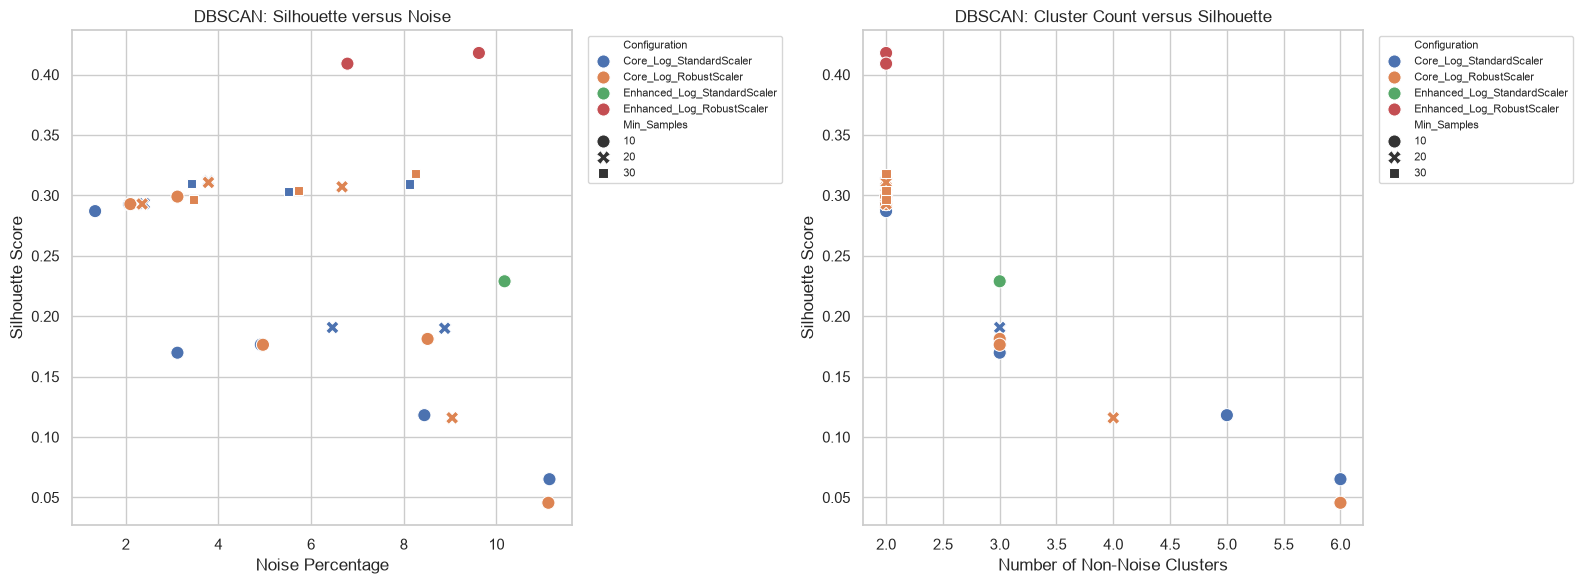

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/dbscan_parameter_search.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=dbscan_results_df,
    x="Noise_Percentage",
    y="Silhouette",
    hue="Configuration",
    style="Min_Samples",
    s=90,
    ax=axes[0]
)

axes[0].set_title("DBSCAN: Silhouette versus Noise")
axes[0].set_xlabel("Noise Percentage")
axes[0].set_ylabel("Silhouette Score")

sns.scatterplot(
    data=dbscan_results_df,
    x="K",
    y="Silhouette",
    hue="Configuration",
    style="Min_Samples",
    s=90,
    ax=axes[1]
)

axes[1].set_title("DBSCAN: Cluster Count versus Silhouette")
axes[1].set_xlabel("Number of Non-Noise Clusters")
axes[1].set_ylabel("Silhouette Score")

for axis in axes:
    axis.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

plt.tight_layout()

dbscan_figure_path = (
    FIGURES_DIR / "dbscan_parameter_search.png"
)

plt.savefig(
    dbscan_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", dbscan_figure_path)

## 5. Random-Seed Stability Analysis

A useful customer-segmentation model should not change substantially because of a different random initialization.

Selected K-Means and Gaussian Mixture candidates are therefore refitted using multiple random seeds. Their labels are compared with the fixed-seed (`random_state=42`) solution using the Adjusted Rand Index (ARI).

- ARI close to 1 indicates highly consistent assignments.
- ARI close to 0 indicates unstable assignments.
- Agglomerative clustering and DBSCAN are deterministic for fixed data and parameters, so random-seed testing is not applicable to them.

In [20]:
stability_candidate_specs = [
    {
        "Candidate": "KMeans_Core_Log_Robust_k3",
        "Algorithm": "KMeans",
        "Configuration": "Core_Log_RobustScaler",
        "K": 3,
    },
    {
        "Candidate": "KMeans_Core_Log_Standard_k3",
        "Algorithm": "KMeans",
        "Configuration": "Core_Log_StandardScaler",
        "K": 3,
    },
    {
        "Candidate": "KMeans_Core_Log_Robust_k4",
        "Algorithm": "KMeans",
        "Configuration": "Core_Log_RobustScaler",
        "K": 4,
    },
    {
        "Candidate": "KMeans_Core_Log_Standard_k4",
        "Algorithm": "KMeans",
        "Configuration": "Core_Log_StandardScaler",
        "K": 4,
    },
    {
        "Candidate": "KMeans_Core_Log_Standard_k5",
        "Algorithm": "KMeans",
        "Configuration": "Core_Log_StandardScaler",
        "K": 5,
    },
    {
        "Candidate": "KMeans_Enhanced_Log_Robust_k5",
        "Algorithm": "KMeans",
        "Configuration": "Enhanced_Log_RobustScaler",
        "K": 5,
    },
    {
        "Candidate": "GMM_Core_Log_Robust_k3",
        "Algorithm": "GaussianMixture",
        "Configuration": "Core_Log_RobustScaler",
        "K": 3,
    },
    {
        "Candidate": "GMM_Core_Log_Standard_k3",
        "Algorithm": "GaussianMixture",
        "Configuration": "Core_Log_StandardScaler",
        "K": 3,
    },
]

stability_seeds = [
    0, 1, 7, 21, 42, 84, 101, 123, 202, 999
]

print(
    "Stability candidates:",
    len(stability_candidate_specs)
)

print(
    "Random seeds:",
    stability_seeds
)

Stability candidates: 8
Random seeds: [0, 1, 7, 21, 42, 84, 101, 123, 202, 999]


In [21]:
stability_rows = []
reference_label_store = {}

for specification in stability_candidate_specs:
    candidate_name = specification["Candidate"]
    algorithm_name = specification["Algorithm"]
    configuration_name = specification["Configuration"]
    k = specification["K"]

    X = scaled_configurations[
        configuration_name
    ]["X"]

    if algorithm_name == "KMeans":
        reference_model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=20
        )
    else:
        reference_model = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=RANDOM_STATE,
            n_init=5,
            reg_covar=1e-6
        )

    reference_labels = reference_model.fit_predict(X)
    reference_label_store[candidate_name] = reference_labels

    for seed in stability_seeds:
        if algorithm_name == "KMeans":
            model = KMeans(
                n_clusters=k,
                random_state=seed,
                n_init=20
            )
        else:
            model = GaussianMixture(
                n_components=k,
                covariance_type="full",
                random_state=seed,
                n_init=5,
                reg_covar=1e-6
            )

        labels = model.fit_predict(X)

        stability_rows.append({
            "Candidate": candidate_name,
            "Algorithm": algorithm_name,
            "Configuration": configuration_name,
            "K": k,
            "Seed": seed,
            "ARI_vs_Seed_42": adjusted_rand_score(
                reference_labels,
                labels
            ),
        })

stability_results_df = pd.DataFrame(stability_rows)

assert len(stability_results_df) == (
    len(stability_candidate_specs)
    * len(stability_seeds)
)

print(
    "Stability experiments completed:",
    len(stability_results_df)
)

display(stability_results_df.head())

Stability experiments completed: 80


,Candidate,Algorithm,Configuration,K,Seed,ARI_vs_Seed_42
0,KMeans_Core_Log_Robust_k3,KMeans,Core_Log_RobustScaler,3,0,1.00
1,KMeans_Core_Log_Robust_k3,KMeans,Core_Log_RobustScaler,3,1,0.98
2,KMeans_Core_Log_Robust_k3,KMeans,Core_Log_RobustScaler,3,7,0.99
3,KMeans_Core_Log_Robust_k3,KMeans,Core_Log_RobustScaler,3,21,0.98
4,KMeans_Core_Log_Robust_k3,KMeans,Core_Log_RobustScaler,3,42,1.00


In [22]:
stability_summary = (
    stability_results_df
    .groupby(
        [
            "Candidate",
            "Algorithm",
            "Configuration",
            "K"
        ],
        as_index=False
    )
    .agg(
        Mean_ARI=("ARI_vs_Seed_42", "mean"),
        Minimum_ARI=("ARI_vs_Seed_42", "min"),
        ARI_Standard_Deviation=(
            "ARI_vs_Seed_42",
            "std"
        )
    )
    .sort_values(
        ["Mean_ARI", "Minimum_ARI"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(stability_summary)

,Candidate,Algorithm,Configuration,K,Mean_ARI,Minimum_ARI,ARI_Standard_Deviation
0,GMM_Core_Log_Robust_k3,GaussianMixture,Core_Log_RobustScaler,3,1.00,0.99,0.00
1,GMM_Core_Log_Standard_k3,GaussianMixture,Core_Log_StandardScaler,3,1.00,1.00,0.00
2,KMeans_Enhanced_Log_Robust_k5,KMeans,Enhanced_Log_RobustScaler,5,1.00,0.99,0.00
3,KMeans_Core_Log_Standard_k3,KMeans,Core_Log_StandardScaler,3,1.00,0.99,0.00
4,KMeans_Core_Log_Robust_k3,KMeans,Core_Log_RobustScaler,3,0.99,0.98,0.01
5,KMeans_Core_Log_Standard_k5,KMeans,Core_Log_StandardScaler,5,0.99,0.98,0.01
6,KMeans_Core_Log_Standard_k4,KMeans,Core_Log_StandardScaler,4,0.98,0.95,0.02
7,KMeans_Core_Log_Robust_k4,KMeans,Core_Log_RobustScaler,4,0.96,0.92,0.03


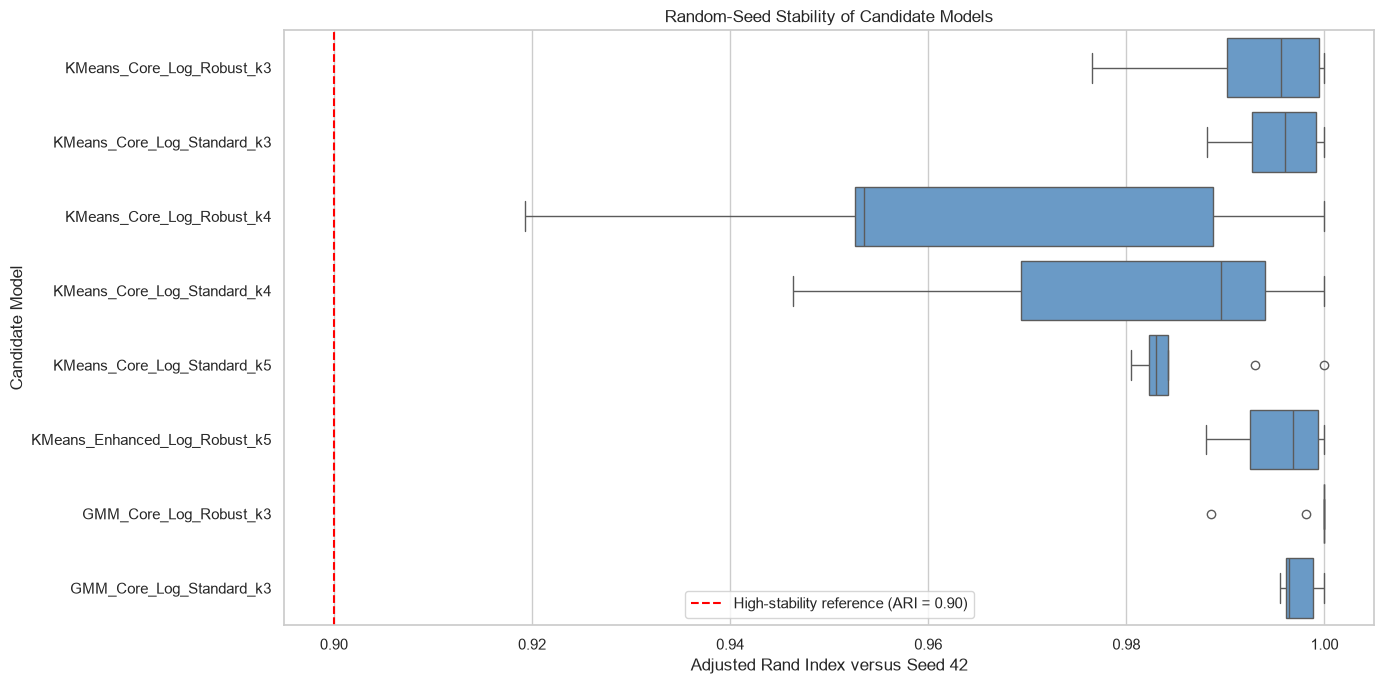

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/candidate_seed_stability.png


In [23]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=stability_results_df,
    y="Candidate",
    x="ARI_vs_Seed_42",
    color="#5B9BD5"
)

plt.axvline(
    0.90,
    color="red",
    linestyle="--",
    label="High-stability reference (ARI = 0.90)"
)

plt.title("Random-Seed Stability of Candidate Models")
plt.xlabel("Adjusted Rand Index versus Seed 42")
plt.ylabel("Candidate Model")
plt.legend()
plt.tight_layout()

stability_figure_path = (
    FIGURES_DIR / "candidate_seed_stability.png"
)

plt.savefig(
    stability_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", stability_figure_path)

## 6. Resampling Stability Analysis

Random-seed stability alone does not test sensitivity to changes in the customer sample.

The leading K-Means candidates are therefore repeatedly trained on random 80% customer subsamples. Each fitted model then predicts cluster labels for the complete customer dataset. These assignments are compared with the full-data reference solution using Adjusted Rand Index.

This assesses whether the discovered customer structure remains consistent when the training sample changes.

In [24]:
resampling_candidate_specs = [
    {
        "Candidate": "KMeans_Core_Log_Standard_k3",
        "Configuration": "Core_Log_StandardScaler",
        "K": 3,
    },
    {
        "Candidate": "KMeans_Core_Log_Standard_k4",
        "Configuration": "Core_Log_StandardScaler",
        "K": 4,
    },
    {
        "Candidate": "KMeans_Core_Log_Standard_k5",
        "Configuration": "Core_Log_StandardScaler",
        "K": 5,
    },
    {
        "Candidate": "KMeans_Core_Log_Robust_k4",
        "Configuration": "Core_Log_RobustScaler",
        "K": 4,
    },
    {
        "Candidate": "KMeans_Enhanced_Log_Robust_k5",
        "Configuration": "Enhanced_Log_RobustScaler",
        "K": 5,
    },
]

resampling_iterations = 30
resampling_fraction = 0.80

print(
    "Resampling candidates:",
    len(resampling_candidate_specs)
)
print(
    "Iterations per candidate:",
    resampling_iterations
)
print(
    "Training fraction:",
    resampling_fraction
)

Resampling candidates: 5
Iterations per candidate: 30
Training fraction: 0.8


In [25]:
resampling_rows = []

for specification in resampling_candidate_specs:
    candidate_name = specification["Candidate"]
    configuration_name = specification["Configuration"]
    k = specification["K"]

    X = scaled_configurations[
        configuration_name
    ]["X"]

    reference_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    reference_labels = reference_model.fit_predict(X)

    for iteration in range(resampling_iterations):
        rng = np.random.default_rng(
            RANDOM_STATE + iteration
        )

        sample_indices = rng.choice(
            len(X),
            size=int(
                len(X) * resampling_fraction
            ),
            replace=False
        )

        sample_model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE + iteration,
            n_init=20
        )

        sample_model.fit(X[sample_indices])

        predicted_full_labels = sample_model.predict(X)

        resampling_rows.append({
            "Candidate": candidate_name,
            "Configuration": configuration_name,
            "K": k,
            "Iteration": iteration + 1,
            "Training_Customers": len(sample_indices),
            "ARI_vs_Full_Data": adjusted_rand_score(
                reference_labels,
                predicted_full_labels
            ),
        })

resampling_results_df = pd.DataFrame(
    resampling_rows
)

assert len(resampling_results_df) == (
    len(resampling_candidate_specs)
    * resampling_iterations
)

print(
    "Resampling experiments completed:",
    len(resampling_results_df)
)

display(resampling_results_df.head())

Resampling experiments completed: 150


,Candidate,Configuration,K,Iteration,Training_Customers,ARI_vs_Full_Data
0,KMeans_Core_Log_Standard_k3,Core_Log_StandardScaler,3,1,3467,1.00
1,KMeans_Core_Log_Standard_k3,Core_Log_StandardScaler,3,2,3467,0.98
2,KMeans_Core_Log_Standard_k3,Core_Log_StandardScaler,3,3,3467,0.94
3,KMeans_Core_Log_Standard_k3,Core_Log_StandardScaler,3,4,3467,0.99
4,KMeans_Core_Log_Standard_k3,Core_Log_StandardScaler,3,5,3467,0.99


In [26]:
resampling_stability_summary = (
    resampling_results_df
    .groupby(
        [
            "Candidate",
            "Configuration",
            "K"
        ],
        as_index=False
    )
    .agg(
        Mean_ARI=("ARI_vs_Full_Data", "mean"),
        Median_ARI=("ARI_vs_Full_Data", "median"),
        Minimum_ARI=("ARI_vs_Full_Data", "min"),
        Maximum_ARI=("ARI_vs_Full_Data", "max"),
        ARI_Standard_Deviation=(
            "ARI_vs_Full_Data",
            "std"
        )
    )
    .sort_values(
        ["Mean_ARI", "Minimum_ARI"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(resampling_stability_summary)

,Candidate,Configuration,K,Mean_ARI,Median_ARI,Minimum_ARI,Maximum_ARI,ARI_Standard_Deviation
0,KMeans_Core_Log_Standard_k3,Core_Log_StandardScaler,3,0.97,0.98,0.89,1.00,0.03
1,KMeans_Enhanced_Log_Robust_k5,Enhanced_Log_RobustScaler,5,0.96,0.97,0.82,0.99,0.03
2,KMeans_Core_Log_Standard_k4,Core_Log_StandardScaler,4,0.94,0.95,0.77,0.99,0.04
3,KMeans_Core_Log_Standard_k5,Core_Log_StandardScaler,5,0.93,0.93,0.82,0.99,0.05
4,KMeans_Core_Log_Robust_k4,Core_Log_RobustScaler,4,0.93,0.93,0.84,0.99,0.03


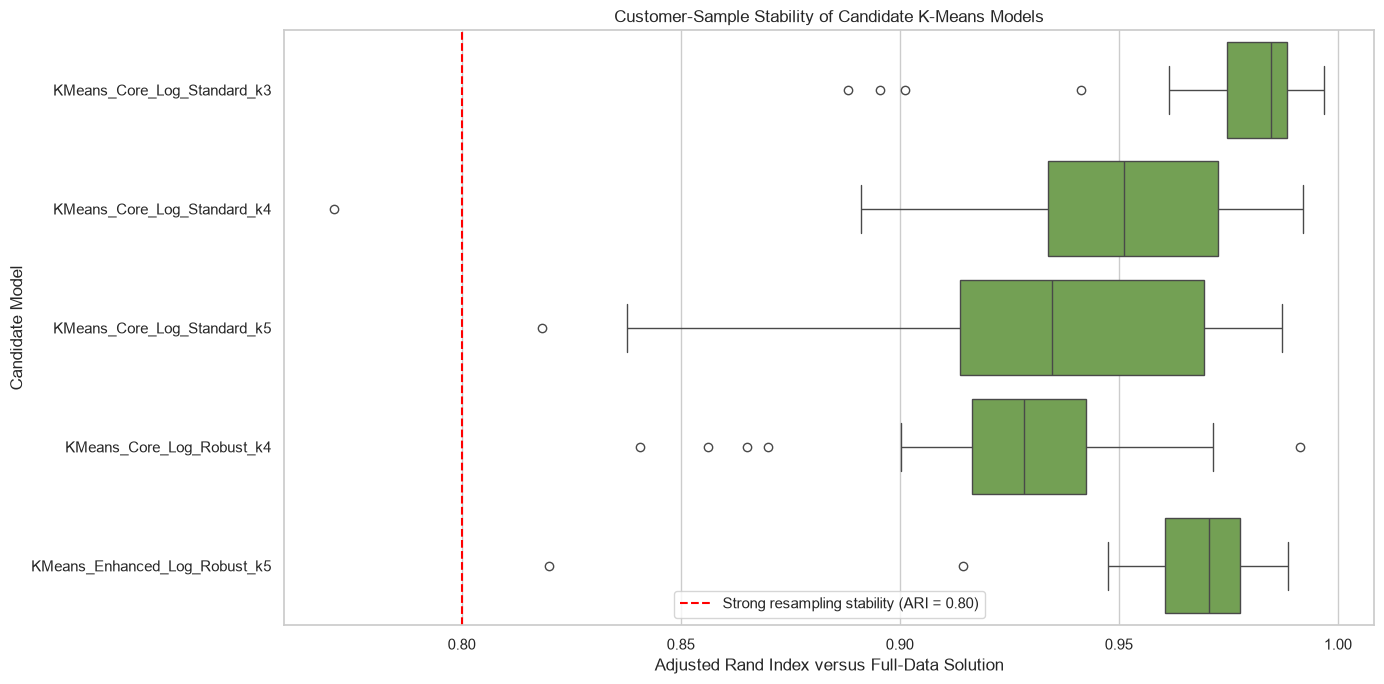

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/candidate_resampling_stability.png


In [27]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=resampling_results_df,
    y="Candidate",
    x="ARI_vs_Full_Data",
    color="#70AD47"
)

plt.axvline(
    0.80,
    color="red",
    linestyle="--",
    label="Strong resampling stability (ARI = 0.80)"
)

plt.title(
    "Customer-Sample Stability of Candidate K-Means Models"
)
plt.xlabel(
    "Adjusted Rand Index versus Full-Data Solution"
)
plt.ylabel("Candidate Model")
plt.legend()
plt.tight_layout()

resampling_figure_path = (
    FIGURES_DIR / "candidate_resampling_stability.png"
)

plt.savefig(
    resampling_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", resampling_figure_path)

## 7. Candidate Segment Profiling

Internal metrics and stability cannot determine whether clusters are useful to the business. The leading Core Log StandardScaler K-Means solutions (`k=3`, `k=4`, and `k=5`) are therefore profiled using the original, untransformed customer measures.

Cluster numbers produced by clustering algorithms are arbitrary. For easier comparison, clusters are reordered from lower to higher median Monetary value within each candidate solution.

In [28]:
candidate_profile_rows = []
candidate_assignment_store = {}

profile_variables = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "ProductDiversity",
    "AverageOrderValue",
    "AverageBasketSize",
    "TenureDays",
]

configuration_name = "Core_Log_StandardScaler"
X_candidate = scaled_configurations[
    configuration_name
]["X"]

customer_ids = scaled_configurations[
    configuration_name
]["CustomerID"]

for k in [3, 4, 5]:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    raw_labels = model.fit_predict(X_candidate)

    assignments = pd.DataFrame({
        "CustomerID": customer_ids,
        "Raw_Cluster": raw_labels
    })

    monetary_order = (
        assignments
        .merge(
            full_features[
                ["CustomerID", "Monetary"]
            ],
            on="CustomerID",
            how="left"
        )
        .groupby("Raw_Cluster")["Monetary"]
        .median()
        .sort_values()
        .index
        .tolist()
    )

    ordered_label_map = {
        raw_cluster: ordered_cluster
        for ordered_cluster, raw_cluster
        in enumerate(monetary_order, start=1)
    }

    assignments["Ordered_Cluster"] = (
        assignments["Raw_Cluster"]
        .map(ordered_label_map)
    )

    candidate_assignment_store[k] = assignments.copy()

    profiled_data = full_features.merge(
        assignments[
            ["CustomerID", "Ordered_Cluster"]
        ],
        on="CustomerID",
        how="inner"
    )

    for cluster, cluster_data in profiled_data.groupby(
        "Ordered_Cluster"
    ):
        profile_row = {
            "Candidate_K": k,
            "Cluster": int(cluster),
            "Customers": len(cluster_data),
            "Customer_Percentage": (
                len(cluster_data)
                / len(profiled_data)
                * 100
            ),
            "Revenue_Percentage": (
                cluster_data["Monetary"].sum()
                / profiled_data["Monetary"].sum()
                * 100
            ),
        }

        for variable in profile_variables:
            profile_row[
                f"Median_{variable}"
            ] = cluster_data[variable].median()

            profile_row[
                f"Mean_{variable}"
            ] = cluster_data[variable].mean()

        candidate_profile_rows.append(profile_row)

candidate_profiles = pd.DataFrame(
    candidate_profile_rows
)

assert candidate_profiles.groupby(
    "Candidate_K"
)["Customers"].sum().eq(4334).all()

display(
    candidate_profiles[
        [
            "Candidate_K",
            "Cluster",
            "Customers",
            "Customer_Percentage",
            "Revenue_Percentage",
            "Median_Recency",
            "Median_Frequency",
            "Median_Monetary",
            "Median_ProductDiversity",
            "Median_AverageBasketSize",
        ]
    ]
)

,Candidate_K,Cluster,Customers,Customer_Percentage,Revenue_Percentage,Median_Recency,Median_Frequency,Median_Monetary,Median_ProductDiversity,Median_AverageBasketSize
0,3,1,1870,43.15,7.67,160.00,1.00,292.24,17.00,14.00
1,3,2,1709,39.43,24.23,30.00,3.00,955.26,50.00,19.00
2,3,3,755,17.42,68.10,10.00,10.00,"3,639.31",116.00,18.00
3,4,1,1598,36.87,6.46,182.00,1.00,299.68,17.00,14.00
4,4,2,878,20.26,5.19,19.00,2.00,439.55,29.00,17.50
5,4,3,1159,26.74,23.97,53.00,4.00,"1,358.74",61.00,19.40
6,4,4,699,16.13,64.38,9.00,10.00,"3,683.26",117.00,18.00
7,5,1,1136,26.21,3.50,219.00,1.00,239.44,14.00,13.00
8,5,2,869,20.05,3.67,26.00,1.00,335.86,24.00,16.50
9,5,3,1006,23.21,16.28,83.00,3.00,980.74,44.50,19.00


In [29]:
candidate_tradeoff_rows = []

for k in [3, 4, 5]:
    experiment_id = (
        f"KMeans_Core_Log_StandardScaler_k{k}"
    )

    metric_row = (
        kmeans_results_df[
            kmeans_results_df["Experiment_ID"]
            == experiment_id
        ]
        .iloc[0]
    )

    stability_candidate = (
        f"KMeans_Core_Log_Standard_k{k}"
    )

    seed_row = (
        stability_summary[
            stability_summary["Candidate"]
            == stability_candidate
        ]
        .iloc[0]
    )

    resampling_row = (
        resampling_stability_summary[
            resampling_stability_summary["Candidate"]
            == stability_candidate
        ]
        .iloc[0]
    )

    candidate_tradeoff_rows.append({
        "Candidate": stability_candidate,
        "K": k,
        "Silhouette": metric_row["Silhouette"],
        "Davies_Bouldin": metric_row["Davies_Bouldin"],
        "Calinski_Harabasz": metric_row[
            "Calinski_Harabasz"
        ],
        "Smallest_Cluster_Percentage": metric_row[
            "Smallest_Cluster_Percentage"
        ],
        "Largest_Cluster_Percentage": metric_row[
            "Largest_Cluster_Percentage"
        ],
        "Seed_Mean_ARI": seed_row["Mean_ARI"],
        "Resampling_Mean_ARI": resampling_row[
            "Mean_ARI"
        ],
        "Resampling_Minimum_ARI": resampling_row[
            "Minimum_ARI"
        ],
    })

candidate_tradeoff_summary = pd.DataFrame(
    candidate_tradeoff_rows
)

display(candidate_tradeoff_summary)

,Candidate,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Seed_Mean_ARI,Resampling_Mean_ARI,Resampling_Minimum_ARI
0,KMeans_Core_Log_Standard_k3,3,0.34,1.04,"3,639.78",17.42,43.15,1.00,0.97,0.89
1,KMeans_Core_Log_Standard_k4,4,0.33,1.02,"3,345.45",16.13,36.87,0.98,0.94,0.77
2,KMeans_Core_Log_Standard_k5,5,0.32,0.98,"3,230.99",8.26,26.21,0.99,0.93,0.82


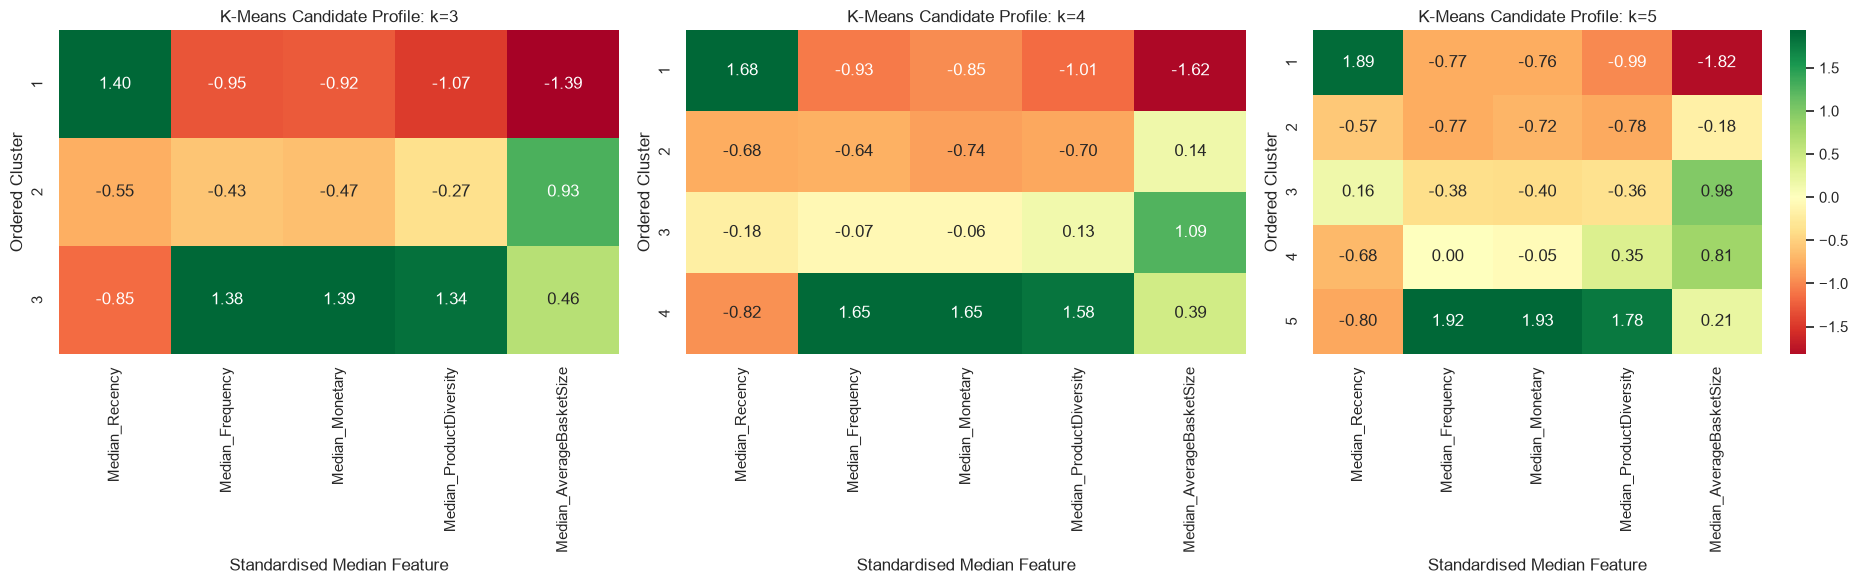

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/kmeans_candidate_profile_comparison.png


In [30]:
heatmap_variables = [
    "Median_Recency",
    "Median_Frequency",
    "Median_Monetary",
    "Median_ProductDiversity",
    "Median_AverageBasketSize",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6)
)

for axis, k in zip(axes, [3, 4, 5]):
    profile_subset = (
        candidate_profiles[
            candidate_profiles["Candidate_K"] == k
        ]
        .set_index("Cluster")[
            heatmap_variables
        ]
    )

    standardised_profile = (
        profile_subset - profile_subset.mean()
    ) / profile_subset.std(ddof=0)

    sns.heatmap(
        standardised_profile,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        ax=axis,
        cbar=k == 5
    )

    axis.set_title(f"K-Means Candidate Profile: k={k}")
    axis.set_xlabel("Standardised Median Feature")
    axis.set_ylabel("Ordered Cluster")

plt.tight_layout()

profile_figure_path = (
    FIGURES_DIR / "kmeans_candidate_profile_comparison.png"
)

plt.savefig(
    profile_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", profile_figure_path)

## 8. Final Model Selection

The final segmentation model is:

- **Algorithm:** K-Means
- **Feature set:** Core RFM
- **Transformation:** log1p
- **Scaling:** StandardScaler
- **Number of clusters:** 5
- **Random state:** 42
- **Initialisations:** 20

Although the three-cluster solution achieved a slightly higher silhouette score, it produced broad customer groups with limited marketing detail. The five-cluster solution was selected because it:

- Achieved a competitive silhouette score of approximately 0.32
- Produced the lowest Davies–Bouldin index among the shortlisted solutions
- Maintained practical cluster sizes between approximately 8% and 26%
- Demonstrated strong random-seed and customer-resampling stability
- Produced five distinct and actionable purchasing profiles
- Better supports downstream segment-specific association mining

The raw-feature solutions with extremely high silhouette scores were rejected because they assigned more than 99% of customers to a single cluster and mainly isolated extreme observations.

In [31]:
FINAL_CONFIGURATION = "Core_Log_StandardScaler"
FINAL_K = 5

final_X = scaled_configurations[
    FINAL_CONFIGURATION
]["X"]

final_customer_ids = scaled_configurations[
    FINAL_CONFIGURATION
]["CustomerID"]

final_model = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

final_raw_labels = final_model.fit_predict(final_X)

final_raw_assignments = pd.DataFrame({
    "CustomerID": final_customer_ids,
    "RawCluster": final_raw_labels
})

raw_cluster_monetary_order = (
    final_raw_assignments
    .merge(
        full_features[
            ["CustomerID", "Monetary"]
        ],
        on="CustomerID",
        how="left"
    )
    .groupby("RawCluster")["Monetary"]
    .median()
    .sort_values()
    .index
    .tolist()
)

ordered_cluster_map = {
    raw_cluster: ordered_cluster
    for ordered_cluster, raw_cluster
    in enumerate(
        raw_cluster_monetary_order,
        start=1
    )
}

segment_name_map = {
    1: "Hibernating Low Value",
    2: "Recent Low Engagement",
    3: "At Risk Regular",
    4: "Loyal High Value",
    5: "Champions",
}

final_raw_assignments["Cluster"] = (
    final_raw_assignments["RawCluster"]
    .map(ordered_cluster_map)
)

final_raw_assignments["Segment"] = (
    final_raw_assignments["Cluster"]
    .map(segment_name_map)
)

final_customer_segments = (
    full_features
    .merge(
        final_raw_assignments[
            ["CustomerID", "Cluster", "Segment"]
        ],
        on="CustomerID",
        how="inner"
    )
)

assert len(final_customer_segments) == 4334
assert final_customer_segments["CustomerID"].is_unique
assert final_customer_segments["Cluster"].nunique() == 5
assert final_customer_segments["Segment"].isna().sum() == 0

print("Final customer segmentation completed.")
print("Customers:", len(final_customer_segments))
print("Segments:", final_customer_segments["Segment"].nunique())

display(
    final_customer_segments[
        [
            "CustomerID",
            "Recency",
            "Frequency",
            "Monetary",
            "Cluster",
            "Segment"
        ]
    ].head()
)

Final customer segmentation completed.
Customers: 4334
Segments: 5


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,"77,183.60",3,At Risk Regular
1,12347,3,7,"4,310.00",4,Loyal High Value
2,12348,76,4,"1,437.24",3,At Risk Regular
3,12349,19,1,"1,457.55",2,Recent Low Engagement
4,12350,311,1,294.40,1,Hibernating Low Value


In [32]:
final_segment_profile = (
    final_customer_segments
    .groupby(
        ["Cluster", "Segment"],
        as_index=False
    )
    .agg(
        Customers=("CustomerID", "nunique"),
        Median_Recency=("Recency", "median"),
        Mean_Recency=("Recency", "mean"),
        Median_Frequency=("Frequency", "median"),
        Mean_Frequency=("Frequency", "mean"),
        Median_Monetary=("Monetary", "median"),
        Mean_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum"),
        Median_TotalQuantity=(
            "TotalQuantity",
            "median"
        ),
        Median_ProductDiversity=(
            "ProductDiversity",
            "median"
        ),
        Median_AverageOrderValue=(
            "AverageOrderValue",
            "median"
        ),
        Median_AverageBasketSize=(
            "AverageBasketSize",
            "median"
        ),
        Median_TenureDays=(
            "TenureDays",
            "median"
        ),
    )
)

final_segment_profile["Customer_Percentage"] = (
    final_segment_profile["Customers"]
    / final_segment_profile["Customers"].sum()
    * 100
)

final_segment_profile["Revenue_Percentage"] = (
    final_segment_profile["Total_Revenue"]
    / final_segment_profile["Total_Revenue"].sum()
    * 100
)

final_segment_profile = final_segment_profile[
    [
        "Cluster",
        "Segment",
        "Customers",
        "Customer_Percentage",
        "Revenue_Percentage",
        "Median_Recency",
        "Median_Frequency",
        "Median_Monetary",
        "Mean_Recency",
        "Mean_Frequency",
        "Mean_Monetary",
        "Total_Revenue",
        "Median_TotalQuantity",
        "Median_ProductDiversity",
        "Median_AverageOrderValue",
        "Median_AverageBasketSize",
        "Median_TenureDays",
    ]
]

assert final_segment_profile["Customers"].sum() == 4334
assert np.isclose(
    final_segment_profile[
        "Customer_Percentage"
    ].sum(),
    100
)
assert np.isclose(
    final_segment_profile[
        "Revenue_Percentage"
    ].sum(),
    100
)

display(final_segment_profile)

,Cluster,Segment,Customers,Customer_Percentage,Revenue_Percentage,Median_Recency,Median_Frequency,Median_Monetary,Mean_Recency,Mean_Frequency,Mean_Monetary,Total_Revenue,Median_TotalQuantity,Median_ProductDiversity,Median_AverageOrderValue,Median_AverageBasketSize,Median_TenureDays
0,1,Hibernating Low Value,1136,26.21,3.50,219.00,1.00,239.44,217.03,1.20,269.29,"305,918.55",126.00,14.00,197.81,13.00,0.00
1,2,Recent Low Engagement,869,20.05,3.67,26.00,1.00,335.86,30.14,1.57,369.23,"320,858.77",197.00,24.00,215.08,16.50,0.00
2,3,At Risk Regular,1006,23.21,16.28,83.00,3.00,980.74,107.19,3.05,"1,414.23","1,422,713.41",558.50,44.50,357.34,19.00,147.00
3,4,Loyal High Value,965,22.27,22.71,17.00,5.00,"1,717.36",19.39,5.61,"2,056.27","1,984,297.09","1,012.00",79.00,320.33,18.62,260.00
4,5,Champions,358,8.26,53.83,8.00,15.00,"5,795.00",13.31,20.06,"13,138.10","4,703,439.82","3,369.50",148.00,397.12,17.33,352.00


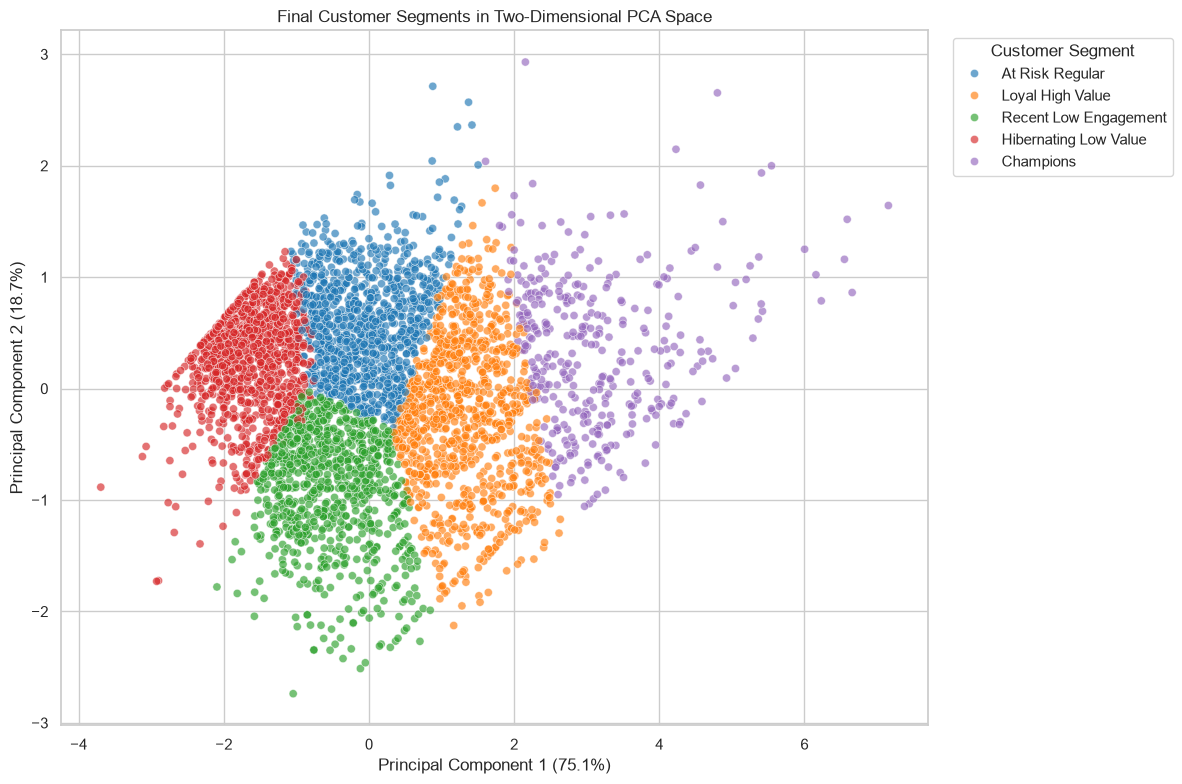

Total variance shown by two PCA components: 93.86%
Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/final_customer_segments_pca.png


In [33]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

final_pca_coordinates = pca.fit_transform(
    final_X
)

final_pca_df = pd.DataFrame({
    "CustomerID": final_customer_ids,
    "PC1": final_pca_coordinates[:, 0],
    "PC2": final_pca_coordinates[:, 1],
    "Segment": final_raw_assignments["Segment"],
})

explained_variance = (
    pca.explained_variance_ratio_.sum() * 100
)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=final_pca_df,
    x="PC1",
    y="PC2",
    hue="Segment",
    palette="tab10",
    alpha=0.65,
    s=35
)

plt.title(
    "Final Customer Segments in Two-Dimensional PCA Space"
)
plt.xlabel(
    f"Principal Component 1 "
    f"({pca.explained_variance_ratio_[0] * 100:.1f}%)"
)
plt.ylabel(
    f"Principal Component 2 "
    f"({pca.explained_variance_ratio_[1] * 100:.1f}%)"
)

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

final_pca_figure_path = (
    FIGURES_DIR / "final_customer_segments_pca.png"
)

plt.savefig(
    final_pca_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Total variance shown by two PCA components: "
    f"{explained_variance:.2f}%"
)
print("Figure saved:", final_pca_figure_path)

## 9. Comparison with the RFM Baseline

The rule-based RFM baseline and final K-Means model serve different purposes:

- The RFM baseline is transparent and easy to explain.
- K-Means discovers customer groups from multivariate distances without manually defining segment boundaries.
- Agreement between them indicates whether the data-driven solution broadly reflects established RFM behaviour.
- Differences are expected because the baseline contains eight manually defined categories while the final model contains five clusters.

In [34]:
from sklearn.metrics import normalized_mutual_info_score

baseline_model_comparison = (
    final_customer_segments[
        ["CustomerID", "Cluster", "Segment"]
    ]
    .merge(
        rfm_baseline[
            ["CustomerID", "BaselineSegment"]
        ],
        on="CustomerID",
        how="inner"
    )
)

baseline_ari = adjusted_rand_score(
    baseline_model_comparison["BaselineSegment"],
    baseline_model_comparison["Segment"]
)

baseline_nmi = normalized_mutual_info_score(
    baseline_model_comparison["BaselineSegment"],
    baseline_model_comparison["Segment"]
)

baseline_cross_tab = pd.crosstab(
    baseline_model_comparison["Segment"],
    baseline_model_comparison["BaselineSegment"],
    normalize="index"
) * 100

assert len(baseline_model_comparison) == 4334

print(
    f"ARI between baseline and final segmentation: "
    f"{baseline_ari:.3f}"
)
print(
    f"NMI between baseline and final segmentation: "
    f"{baseline_nmi:.3f}"
)

display(baseline_cross_tab.round(2))

ARI between baseline and final segmentation: 0.361
NMI between baseline and final segmentation: 0.488


BaselineSegment,At Risk High Value,Champions,Developing Customers,Hibernating,Loyal Customers,Needs Attention,Promising High Value,Recent Customers
Segment,,,,,,,,
At Risk Regular,7.65,0.00,26.44,12.43,12.13,36.38,4.97,0.00
Champions,0.56,79.05,0.00,0.00,18.44,1.68,0.00,0.28
Hibernating Low Value,0.00,0.00,26.94,72.62,0.00,0.44,0.00,0.00
Loyal High Value,0.00,51.40,0.00,0.00,40.62,4.87,0.41,2.69
Recent Low Engagement,0.00,0.00,59.61,0.00,9.21,0.35,4.14,26.70


In [35]:
segment_recommendations = pd.DataFrame([
    {
        "Cluster": 1,
        "Segment": "Hibernating Low Value",
        "Observed_Profile": (
            "Long inactivity, mostly one purchase, "
            "low historical spending"
        ),
        "Primary_Objective": "Low-cost reactivation",
        "Recommended_Action": (
            "Use limited-cost win-back messages, "
            "seasonal reminders and broad popular-product offers"
        ),
        "Association_Mining_Priority": "Low",
    },
    {
        "Cluster": 2,
        "Segment": "Recent Low Engagement",
        "Observed_Profile": (
            "Recently active but mostly one purchase "
            "and low current spending"
        ),
        "Primary_Objective": "Encourage a second purchase",
        "Recommended_Action": (
            "Provide welcome follow-ups, complementary-product "
            "recommendations and second-order incentives"
        ),
        "Association_Mining_Priority": "High",
    },
    {
        "Cluster": 3,
        "Segment": "At Risk Regular",
        "Observed_Profile": (
            "Moderate historical purchasing but declining recency"
        ),
        "Primary_Objective": "Prevent customer loss",
        "Recommended_Action": (
            "Use personalised reactivation campaigns based on "
            "previous categories and frequently paired products"
        ),
        "Association_Mining_Priority": "High",
    },
    {
        "Cluster": 4,
        "Segment": "Loyal High Value",
        "Observed_Profile": (
            "Recent, frequent and high-value purchasing behaviour"
        ),
        "Primary_Objective": "Strengthen loyalty",
        "Recommended_Action": (
            "Offer loyalty rewards, early product access, "
            "cross-selling and relevant multi-product bundles"
        ),
        "Association_Mining_Priority": "Very High",
    },
    {
        "Cluster": 5,
        "Segment": "Champions",
        "Observed_Profile": (
            "Most recent, most frequent and highest-value customers"
        ),
        "Primary_Objective": "Retain and reward",
        "Recommended_Action": (
            "Provide VIP treatment, premium bundles, exclusive "
            "offers and personalised high-value recommendations"
        ),
        "Association_Mining_Priority": "Very High",
    },
])

display(segment_recommendations)

,Cluster,Segment,Observed_Profile,Primary_Objective,Recommended_Action,Association_Mining_Priority
0,1,Hibernating Low Value,"Long inactivity, mostly one purchase, low hist...",Low-cost reactivation,"Use limited-cost win-back messages, seasonal r...",Low
1,2,Recent Low Engagement,Recently active but mostly one purchase and lo...,Encourage a second purchase,"Provide welcome follow-ups, complementary-prod...",High
2,3,At Risk Regular,Moderate historical purchasing but declining r...,Prevent customer loss,Use personalised reactivation campaigns based ...,High
3,4,Loyal High Value,"Recent, frequent and high-value purchasing beh...",Strengthen loyalty,"Offer loyalty rewards, early product access, c...",Very High
4,5,Champions,"Most recent, most frequent and highest-value c...",Retain and reward,"Provide VIP treatment, premium bundles, exclus...",Very High


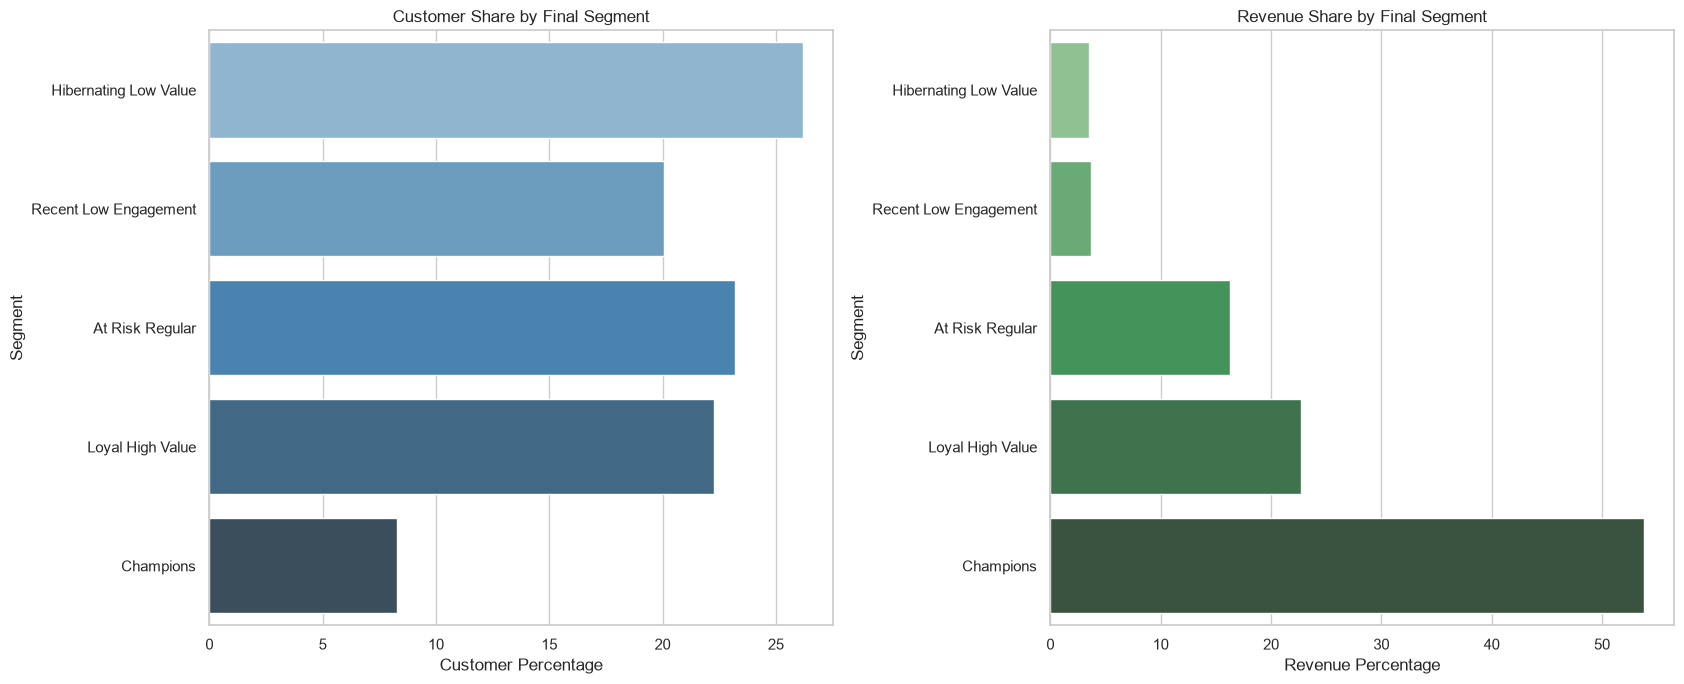

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/final_segment_customer_revenue_share.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

plot_profile = final_segment_profile.sort_values(
    "Cluster"
)

sns.barplot(
    data=plot_profile,
    y="Segment",
    x="Customer_Percentage",
    hue="Segment",
    palette="Blues_d",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Customer Share by Final Segment")
axes[0].set_xlabel("Customer Percentage")
axes[0].set_ylabel("Segment")

sns.barplot(
    data=plot_profile,
    y="Segment",
    x="Revenue_Percentage",
    hue="Segment",
    palette="Greens_d",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Revenue Share by Final Segment")
axes[1].set_xlabel("Revenue Percentage")
axes[1].set_ylabel("Segment")

plt.tight_layout()

final_distribution_figure_path = (
    FIGURES_DIR / "final_segment_customer_revenue_share.png"
)

plt.savefig(
    final_distribution_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    final_distribution_figure_path
)

In [37]:
kmeans_audit = kmeans_results_df.copy()

alternative_audit = algorithm_results_df[
    algorithm_results_df["Algorithm"] != "KMeans"
].copy()

complete_model_comparison = pd.concat(
    [
        kmeans_audit,
        alternative_audit,
        dbscan_results_df
    ],
    ignore_index=True,
    sort=False
)

complete_model_comparison = (
    complete_model_comparison
    .drop_duplicates(
        subset=["Experiment_ID"]
    )
    .reset_index(drop=True)
)

final_model_summary = pd.DataFrame([{
    "Selected_Algorithm": "KMeans",
    "Selected_Configuration": FINAL_CONFIGURATION,
    "Selected_Features": (
        "Log_Recency, Log_Frequency, Log_Monetary"
    ),
    "Scaler": "StandardScaler",
    "Number_of_Clusters": FINAL_K,
    "Random_State": RANDOM_STATE,
    "N_Init": 20,
    "Silhouette": float(
        candidate_tradeoff_summary.loc[
            candidate_tradeoff_summary["K"] == FINAL_K,
            "Silhouette"
        ].iloc[0]
    ),
    "Davies_Bouldin": float(
        candidate_tradeoff_summary.loc[
            candidate_tradeoff_summary["K"] == FINAL_K,
            "Davies_Bouldin"
        ].iloc[0]
    ),
    "Calinski_Harabasz": float(
        candidate_tradeoff_summary.loc[
            candidate_tradeoff_summary["K"] == FINAL_K,
            "Calinski_Harabasz"
        ].iloc[0]
    ),
    "Seed_Mean_ARI": float(
        candidate_tradeoff_summary.loc[
            candidate_tradeoff_summary["K"] == FINAL_K,
            "Seed_Mean_ARI"
        ].iloc[0]
    ),
    "Resampling_Mean_ARI": float(
        candidate_tradeoff_summary.loc[
            candidate_tradeoff_summary["K"] == FINAL_K,
            "Resampling_Mean_ARI"
        ].iloc[0]
    ),
    "Resampling_Minimum_ARI": float(
        candidate_tradeoff_summary.loc[
            candidate_tradeoff_summary["K"] == FINAL_K,
            "Resampling_Minimum_ARI"
        ].iloc[0]
    ),
    "Baseline_ARI": baseline_ari,
    "Baseline_NMI": baseline_nmi,
    "Selection_Reason": (
        "Competitive internal metrics, practical cluster "
        "sizes, strong stability, clear business profiles "
        "and useful detail for segment-specific association mining"
    )
}])

print(
    "Unique evaluated experiments:",
    len(complete_model_comparison)
)

display(final_model_summary)

Unique evaluated experiments: 192


,Selected_Algorithm,Selected_Configuration,Selected_Features,Scaler,Number_of_Clusters,Random_State,N_Init,Silhouette,Davies_Bouldin,Calinski_Harabasz,Seed_Mean_ARI,Resampling_Mean_ARI,Resampling_Minimum_ARI,Baseline_ARI,Baseline_NMI,Selection_Reason
0,KMeans,Core_Log_StandardScaler,"Log_Recency, Log_Frequency, Log_Monetary",StandardScaler,5,42,20,0.32,0.98,"3,230.99",0.99,0.93,0.82,0.36,0.49,"Competitive internal metrics, practical cluste..."


In [38]:
segment_assignment_output = (
    final_customer_segments[
        [
            "CustomerID",
            "Cluster",
            "Segment",
            "PrimaryCountry"
        ]
    ]
    .sort_values("CustomerID")
    .reset_index(drop=True)
)

processed_outputs = {
    "customer_segment_assignments.csv":
        segment_assignment_output,
    "customer_features_with_segments.csv":
        final_customer_segments.sort_values(
            "CustomerID"
        ).reset_index(drop=True),
}

documentation_outputs = {
    "clustering_model_comparison.csv":
        complete_model_comparison,
    "final_model_summary.csv":
        final_model_summary,
    "final_segment_profile.csv":
        final_segment_profile,
    "segment_recommendations.csv":
        segment_recommendations,
    "clustering_seed_stability.csv":
        stability_summary,
    "clustering_resampling_stability.csv":
        resampling_stability_summary,
    "rfm_baseline_segment_summary.csv":
        baseline_segment_summary,
    "candidate_model_tradeoff.csv":
        candidate_tradeoff_summary,
}

for filename, dataframe in processed_outputs.items():
    output_path = PROCESSED_DIR / filename
    dataframe.to_csv(output_path, index=False)
    print(
        f"Saved processed output: "
        f"{filename} ({len(dataframe):,} rows)"
    )

for filename, dataframe in documentation_outputs.items():
    output_path = DOCUMENTATION_DIR / filename
    dataframe.to_csv(output_path, index=False)
    print(
        f"Saved documentation: "
        f"{filename} ({len(dataframe):,} rows)"
    )

Saved processed output: customer_segment_assignments.csv (4,334 rows)
Saved processed output: customer_features_with_segments.csv (4,334 rows)
Saved documentation: clustering_model_comparison.csv (192 rows)
Saved documentation: final_model_summary.csv (1 rows)
Saved documentation: final_segment_profile.csv (5 rows)
Saved documentation: segment_recommendations.csv (5 rows)
Saved documentation: clustering_seed_stability.csv (8 rows)
Saved documentation: clustering_resampling_stability.csv (5 rows)
Saved documentation: rfm_baseline_segment_summary.csv (8 rows)
Saved documentation: candidate_model_tradeoff.csv (3 rows)


In [39]:
def calculate_sha256(file_path):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            sha256.update(block)

    return sha256.hexdigest()


fingerprint_rows = []

for filename, dataframe in processed_outputs.items():
    file_path = PROCESSED_DIR / filename

    fingerprint_rows.append({
        "Dataset": file_path.stem,
        "Filename": filename,
        "Rows": len(dataframe),
        "Columns": dataframe.shape[1],
        "File_Size_MB": (
            file_path.stat().st_size / (1024 ** 2)
        ),
        "SHA256": calculate_sha256(file_path),
        "Produced_By": (
            "Palliyaguruge C.T. (IT24103655)"
        ),
        "Downstream_Consumer": (
            "Senaratne P.A.R.T. (IT24103526)"
        ),
    })

clustering_output_fingerprints = pd.DataFrame(
    fingerprint_rows
)

fingerprint_path = (
    DOCUMENTATION_DIR
    / "clustering_output_fingerprints.csv"
)

clustering_output_fingerprints.to_csv(
    fingerprint_path,
    index=False
)

display(clustering_output_fingerprints)

,Dataset,Filename,Rows,Columns,File_Size_MB,SHA256,Produced_By,Downstream_Consumer
0,customer_segment_assignments,customer_segment_assignments.csv,4334,4,0.17,8753493be4c5ab3c79262530ad86805430f76605208e28...,Palliyaguruge C.T. (IT24103655),Senaratne P.A.R.T. (IT24103526)
1,customer_features_with_segments,customer_features_with_segments.csv,4334,16,0.54,22e5017193a756ec278d161f881c39883926c69d3d5f9c...,Palliyaguruge C.T. (IT24103655),Senaratne P.A.R.T. (IT24103526)


In [40]:
reloaded_assignments = pd.read_csv(
    PROCESSED_DIR
    / "customer_segment_assignments.csv"
)

reloaded_features_with_segments = pd.read_csv(
    PROCESSED_DIR
    / "customer_features_with_segments.csv"
)

assert len(reloaded_assignments) == 4334
assert reloaded_assignments["CustomerID"].is_unique
assert reloaded_assignments["Cluster"].nunique() == 5
assert reloaded_assignments["Segment"].nunique() == 5
assert reloaded_assignments.isna().sum().sum() == 0

assert len(reloaded_features_with_segments) == 4334
assert (
    reloaded_features_with_segments[
        "CustomerID"
    ].is_unique
)
assert (
    reloaded_features_with_segments[
        "Segment"
    ].isna().sum()
    == 0
)

assignment_customers = set(
    reloaded_assignments["CustomerID"]
)

feature_customers = set(
    full_features["CustomerID"]
)

assert assignment_customers == feature_customers

print(
    "All saved clustering outputs passed "
    "reload and handover validation."
)
print(
    "Customers handed over:",
    len(reloaded_assignments)
)
print(
    "Segments handed over:",
    reloaded_assignments["Segment"].nunique()
)
print(
    "Downstream member: "
    "Senaratne P.A.R.T. (IT24103526)"
)

All saved clustering outputs passed reload and handover validation.
Customers handed over: 4334
Segments handed over: 5
Downstream member: Senaratne P.A.R.T. (IT24103526)


## 10. Conclusion and Downstream Handover

This notebook completed the customer-segmentation responsibility assigned to **Palliyaguruge C.T. (IT24103655)**.

### Work completed

- Developed an interpretable quartile-based RFM baseline
- Evaluated raw and log1p-transformed feature representations
- Compared StandardScaler and RobustScaler
- Evaluated K-Means for `k=2` through `k=10`
- Evaluated Agglomerative Clustering and Gaussian Mixture Models
- Tuned DBSCAN using nearest-neighbour distance quantiles
- Compared 192 unique clustering experiments
- Evaluated models using Silhouette, Davies–Bouldin and Calinski–Harabasz metrics
- Screened misleading solutions using practical cluster-balance criteria
- Assessed random-seed stability using Adjusted Rand Index
- Assessed customer-resampling stability using 30 repeated 80% samples
- Compared shortlisted `k=3`, `k=4` and `k=5` customer profiles
- Selected and profiled a final five-segment K-Means model
- Created business recommendations and downstream handover datasets

### Final model

- Algorithm: K-Means
- Features: log1p-transformed Recency, Frequency and Monetary
- Scaling: StandardScaler
- Number of clusters: 5
- Random state: 42
- Initialisations: 20
- Silhouette score: approximately 0.32
- Davies–Bouldin index: approximately 0.98
- Mean seed-stability ARI: approximately 0.99
- Mean resampling-stability ARI: approximately 0.93

### Final customer segments

1. Hibernating Low Value
2. Recent Low Engagement
3. At Risk Regular
4. Loyal High Value
5. Champions

The Champions segment contains approximately 8.26% of customers but contributes approximately 53.83% of merchandise revenue. Loyal High Value customers contribute a further 22.71%. These results demonstrate substantial customer-value concentration.

### Downstream handover

**Senaratne P.A.R.T. (IT24103526)** should use:

- `customer_segment_assignments.csv`
- `customer_features_with_segments.csv`
- `merchandise_basket_transactions.csv`

for segment-specific association mining, bundle evaluation and recommendation development.

DBSCAN noise labels were used only for algorithm evaluation. No customers were deleted from the final segmentation dataset.